# COMP9444 Group Project — Fruit and Vegetable Freshness Assessment

**Team 093 · Single aggregated experiment notebook**

This notebook contains the report-aligned experimental workflow: dataset audit and fixed split, a frozen ResNet-18 comparison baseline, frozen DenseNet-201 and ResNeXt-101 feature extraction, train-only scaling/PCA, SVM/LDA/Bagging classification, feature fusion, augmentation/PCA/classifier ablations, validation analysis, error inspection, feature-space visualisation, historical test disclosure, and an optional prediction demo.

The main task maps the original 20 produce-condition folders to **fresh** versus **rotten**. Model selection uses validation Macro-F1. The reported best validation configuration is **DenseNet-201 + PCA(95%) + RBF-SVM without augmentation** (Macro-F1 0.9878). Historical test artifacts are disclosed later and are never used to choose a model in this notebook.


## 1. Research question, objectives and responsibilities

**Research question.** How effectively can frozen ImageNet CNN representations separate fresh from rotten fruit and vegetables, and how do backbone choice, train-only augmentation, PCA and the downstream classifier affect validation performance and efficiency?

**Objectives.** We (1) establish a transparent frozen ResNet-18 comparison baseline, (2) compare DenseNet-201 and ResNeXt-101 under one fixed split, (3) test SVM, LDA and Bagging with and without PCA(95%), (4) assess simple feature fusion, and (5) analyse confusion matrices and difficult images. Macro-F1 is primary because both freshness classes must be handled well; Accuracy and Weighted-F1 are supporting metrics.

**Team workflow.** Person 1 owned the data audit, fixed split and shared protocol; Person 2 owned DenseNet-201 extraction and augmentation analysis; Person 3 owned ResNeXt-101 extraction and visual/error analysis; Person 4 owned PCA, classifiers and fusion; Person 5 integrated the frozen baseline, evaluation, reporting and the final notebook. The code below consolidates those repository components without changing their recorded results.


In [1]:
import io
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

try:
    import kagglehub
except ImportError:
    kagglehub = None
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
try:
    from IPython.display import clear_output, display
except ImportError:
    def display(value):
        print(value)
    def clear_output(wait=False):
        return None
from PIL import Image, ImageOps, UnidentifiedImageError
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLASSES = np.asarray(["fresh", "rotten"])
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
DATASET_HANDLE = "muhriddinmuxiddinov/fruits-and-vegetables-dataset"

# Expensive or interactive stages are opt-in. The submitted notebook keeps all False and
# displays the committed, previously executed artifacts. No flag below evaluates test.
RUN_DATA_PREPARATION = False
RUN_FEATURE_EXTRACTION = False
RUN_VALIDATION_EXPERIMENTS = False
RUN_QUALITATIVE_REBUILD = False
RUN_EMBEDDING_REBUILD = False
RUN_INTERACTIVE_DEMO = False
RUN_FULL_REPRODUCTION = (
    RUN_DATA_PREPARATION or RUN_FEATURE_EXTRACTION
    or RUN_VALIDATION_EXPERIMENTS
)
ALLOW_REPOSITORY_DOWNLOAD = False

def find_repository_root(start: Path) -> Path | None:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "results").is_dir():
            return candidate
    return None


REPOSITORY_ROOT = find_repository_root(Path.cwd())
WORK_DIR = Path("/content/comp9444_team093") if Path("/content").is_dir() else Path.cwd() / "comp9444_team093"
FEATURE_DIR = WORK_DIR / "features"
MODEL_DIR = WORK_DIR / "models"
RESULT_DIR = WORK_DIR / "results"
for directory in (WORK_DIR, FEATURE_DIR, MODEL_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

print("Python:", sys.version.split()[0], "|", platform.system())
print("NumPy:", np.__version__, "| pandas:", pd.__version__, "| sklearn:", sklearn.__version__)
print("PyTorch:", torch.__version__, "| device:", DEVICE)
print("Seed:", SEED, "| work directory:", WORK_DIR)
print("Mode:", "OPT-IN RECOMPUTATION" if RUN_FULL_REPRODUCTION else "SUBMISSION / COMMITTED OUTPUTS")
print("Repository root:", REPOSITORY_ROOT or "not detected (standalone notebook)")


Python: 3.12.13 | Linux
NumPy: 2.0.2 | pandas: 2.2.2 | sklearn: 1.6.1
PyTorch: 2.11.0+cpu | device: cpu
Seed: 42 | work directory: /content/comp9444_team093
Mode: SUBMISSION / COMMITTED OUTPUTS
Repository root: not detected (standalone notebook)


## 2. Dataset source, integrity audit and official split

**Source.** Muhriddin Muxiddinov, *Fruits and Vegetables Dataset*, Kaggle handle `muhriddinmuxiddinov/fruits-and-vegetables-dataset`: https://www.kaggle.com/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset. The project uses 12,000 images in 20 original folders (10 produce types × fresh/rotten). Images are downloaded locally and are not redistributed by this notebook. Dataset terms should be checked on Kaggle before redistribution.

The recorded audit found 12,000 readable images, zero corrupt files, four image formats, 1,585 distinct resolutions and substantial size variation. A deterministic, class-stratified 70/15/15 split with seed 42 gives 8,399 train, 1,801 validation and 1,800 test rows. When full reproduction is enabled, the notebook downloads the Kaggle data and creates the split directly. Submission mode uses the embedded aggregate audit results and requires no external split CSV.


In [2]:
# If the automatic public download is unavailable, set DATA_DIR manually to the
# extracted Kaggle folder before running this cell in full reproduction mode.
DATA_DIR = None


def normalise_label(name: str) -> str:
    return name.strip().lower().replace(" ", "").replace("-", "").replace("_", "")


def binary_label(label: str) -> str:
    value = normalise_label(str(label))
    if value.startswith("fresh"):
        return "fresh"
    if value.startswith("rotten"):
        return "rotten"
    raise ValueError(f"Cannot map label to fresh/rotten: {label!r}")


def scan_images(data_dir: Path) -> pd.DataFrame:
    records = []
    for path in data_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        label = normalise_label(path.parent.name)
        if not (label.startswith("fresh") or label.startswith("rotten")):
            continue
        records.append({"filepath": str(path.resolve()), "label": label})
    frame = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)
    return frame


def create_official_split(frame: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    if frame["filepath"].duplicated().any():
        raise ValueError("Duplicate image paths found before splitting")
    indices = frame.index.to_numpy()
    labels = frame["label"].to_numpy()

    train_val_indices, test_indices = train_test_split(
        indices, test_size=0.15, stratify=labels, random_state=seed,
    )
    validation_relative = 0.15 / (0.70 + 0.15)
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=validation_relative,
        stratify=frame.loc[train_val_indices, "label"].to_numpy(),
        random_state=seed,
    )

    split = pd.Series(index=frame.index, dtype="object")
    split.loc[train_indices] = "train"
    split.loc[val_indices] = "val"
    split.loc[test_indices] = "test"

    output = frame.copy()
    output["split"] = split
    output["binary_label"] = output["label"].map(binary_label)
    return output.sort_values(["split", "label", "filepath"]).reset_index(drop=True)


if RUN_FULL_REPRODUCTION:
    if DATA_DIR is None:
        if kagglehub is None:
            raise ImportError("Install kagglehub or set DATA_DIR to an extracted dataset.")
        print(f"Downloading/caching Kaggle dataset: {DATASET_HANDLE}")
        DATA_DIR = Path(kagglehub.dataset_download(DATASET_HANDLE))
    else:
        DATA_DIR = Path(DATA_DIR)
    if not DATA_DIR.is_dir():
        raise FileNotFoundError(DATA_DIR)

    raw_frame = scan_images(DATA_DIR)
    if len(raw_frame) != 12000 or raw_frame["label"].nunique() != 20:
        raise ValueError(
            f"Expected 12,000 images and 20 original classes; found "
            f"{len(raw_frame):,} images and {raw_frame['label'].nunique()} classes. "
            "Check DATA_DIR and dataset version before continuing."
        )
    official_split = create_official_split(raw_frame)
    split_counts = official_split["split"].value_counts().reindex(["train", "val", "test"])
    split_audit = pd.DataFrame({"count": split_counts, "ratio": split_counts / len(official_split)})
    split_by_class = pd.crosstab(official_split["label"], official_split["split"])
    binary_by_split = pd.crosstab(official_split["binary_label"], official_split["split"])
    print("Dataset root:", DATA_DIR)
    print("Duplicate paths:", int(official_split["filepath"].duplicated().sum()))
else:
    # Exact committed split audit embedded into the single-file submission.
    official_split = None
    split_by_class = pd.DataFrame(json.loads(r'''[{"label":"freshapple","train":428,"val":92,"test":92,"total":612},{"label":"freshbanana","train":436,"val":94,"test":94,"total":624},{"label":"freshbellpepper","train":427,"val":92,"test":92,"total":611},{"label":"freshcarrot","train":434,"val":93,"test":93,"total":620},{"label":"freshcucumber","train":426,"val":91,"test":91,"total":608},{"label":"freshmango","train":423,"val":91,"test":91,"total":605},{"label":"freshorange","train":427,"val":91,"test":91,"total":609},{"label":"freshpotato","train":431,"val":92,"test":92,"total":615},{"label":"freshstrawberry","train":422,"val":91,"test":90,"total":603},{"label":"freshtomato","train":422,"val":91,"test":91,"total":604},{"label":"rottenapple","train":412,"val":88,"test":88,"total":588},{"label":"rottenbanana","train":404,"val":86,"test":86,"total":576},{"label":"rottenbellpepper","train":413,"val":89,"test":89,"total":591},{"label":"rottencarrot","train":406,"val":87,"test":87,"total":580},{"label":"rottencucumber","train":415,"val":89,"test":89,"total":593},{"label":"rottenmango","train":415,"val":89,"test":89,"total":593},{"label":"rottenorange","train":413,"val":89,"test":89,"total":591},{"label":"rottenpotato","train":409,"val":88,"test":88,"total":585},{"label":"rottenstrawberry","train":418,"val":89,"test":89,"total":596},{"label":"rottentomato","train":418,"val":89,"test":89,"total":596},{"label":"ALL","train":8399,"val":1801,"test":1800,"total":12000}]'''))
    split_by_class = split_by_class[split_by_class["label"].ne("ALL")].set_index("label")
    split_by_class = split_by_class[["train", "val", "test"]].astype(int)
    split_counts = pd.Series({"train": 8399, "val": 1801, "test": 1800})
    split_audit = pd.DataFrame({"count": split_counts, "ratio": split_counts / 12000})
    binary_by_split = pd.DataFrame(
        {"train": [4276, 4123], "val": [918, 883], "test": [917, 883]},
        index=["fresh", "rotten"],
    )
    print("Displaying the exact recorded split audit; no dataset download in submission mode.")

print("Rows: 12,000 | original classes: 20 | stratified seed: 42")
display(split_audit)
display(binary_by_split.T.reindex(["train", "val", "test"]))
display(split_by_class)


def inspect_image_file(path: Path) -> dict:
    """Repository-equivalent Pillow integrity, format and resolution audit."""
    record = {"format": None, "width": None, "height": None, "ok": False, "error": ""}
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            record.update(format=image.format, width=image.width, height=image.height, ok=True)
    except Exception as error:
        record["error"] = f"{type(error).__name__}: {error}"
    return record


def audit_dataset(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Inspect every image; use only when RUN_DATA_PREPARATION is enabled."""
    rows = []
    for record in tqdm(frame.itertuples(index=False), total=len(frame), desc="image audit"):
        details = inspect_image_file(Path(record.filepath))
        rows.append({"filepath": record.filepath, "label": record.label, **details})
    image_stats = pd.DataFrame(rows)
    good = image_stats[image_stats["ok"]]
    summary = pd.DataFrame([{
        "total_images": len(image_stats), "readable_images": len(good),
        "corrupt_images": int((~image_stats["ok"]).sum()),
        "num_classes": image_stats["label"].nunique(),
        "formats": ", ".join(f"{k}:{v}" for k, v in good["format"].value_counts().items()),
        "width_min": good["width"].min(), "width_max": good["width"].max(),
        "height_min": good["height"].min(), "height_max": good["height"].max(),
        "unique_sizes": good[["width", "height"]].drop_duplicates().shape[0],
    }])
    return image_stats, summary


Displaying the exact recorded split audit; no dataset download in submission mode.
Rows: 12,000 | original classes: 20 | stratified seed: 42


,count,ratio
train,8399,0.6999
val,1801,0.1501
test,1800,0.1500


,fresh,rotten
train,4276,4123
val,918,883
test,917,883


,train,val,test
label,,,
freshapple,428,92,92
freshbanana,436,94,94
freshbellpepper,427,92,92
freshcarrot,434,93,93
freshcucumber,426,91,91
freshmango,423,91,91
freshorange,427,91,91
freshpotato,431,92,92
freshstrawberry,422,91,90


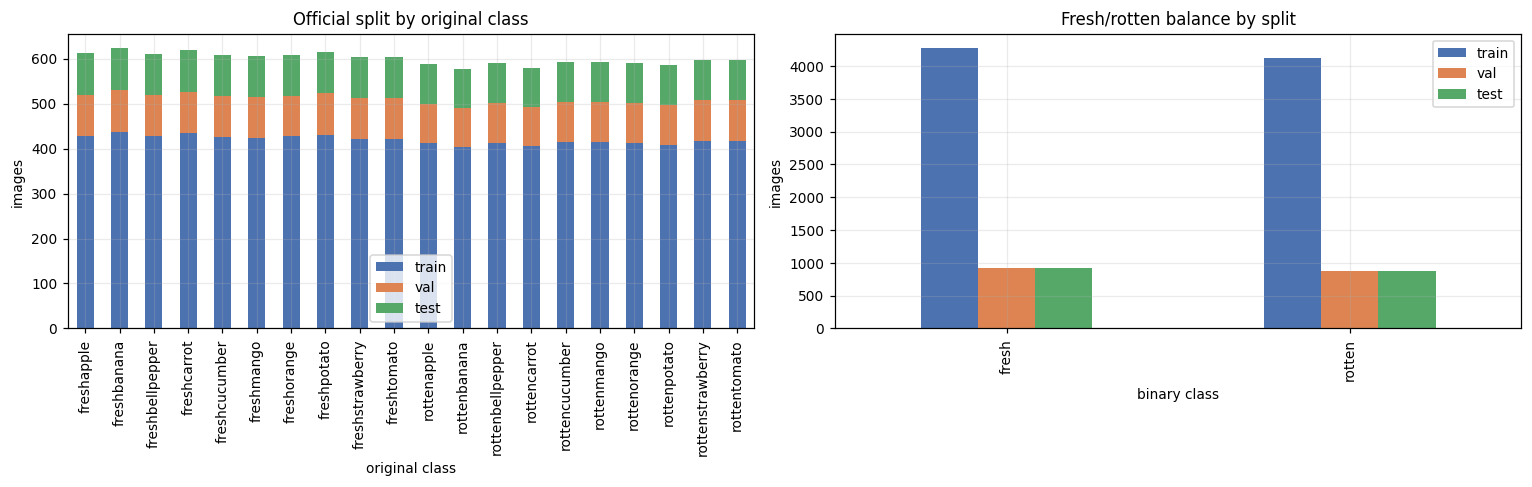

In [3]:
class_counts = split_by_class.reindex(columns=["train", "val", "test"])
binary_counts = binary_by_split.reindex(columns=["train", "val", "test"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_counts.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Official split by original class")
axes[0].set_xlabel("original class"); axes[0].set_ylabel("images")
binary_counts.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Fresh/rotten balance by split")
axes[1].set_xlabel("binary class"); axes[1].set_ylabel("images")
plt.tight_layout(); plt.show()

### 2.1 Recorded data-quality evidence

| Check | Recorded value |
|---|---:|
| Total/readable images | 12,000 / 12,000 |
| Corrupt images | 0 |
| Original classes | 20 |
| Formats | JPEG 9,573; PNG 2,409; WEBP 17; MPO 1 |
| Width range | 80–6,183 px |
| Height range | 95–4,345 px |
| Unique resolutions | 1,585 |

No duplicate file paths occur in the official list. Images are converted to RGB and resized to 224×224, so format and resolution heterogeneity is handled consistently. The audit did not claim that visually identical files with different names were absent, that is a limitation rather than an unverified assertion.

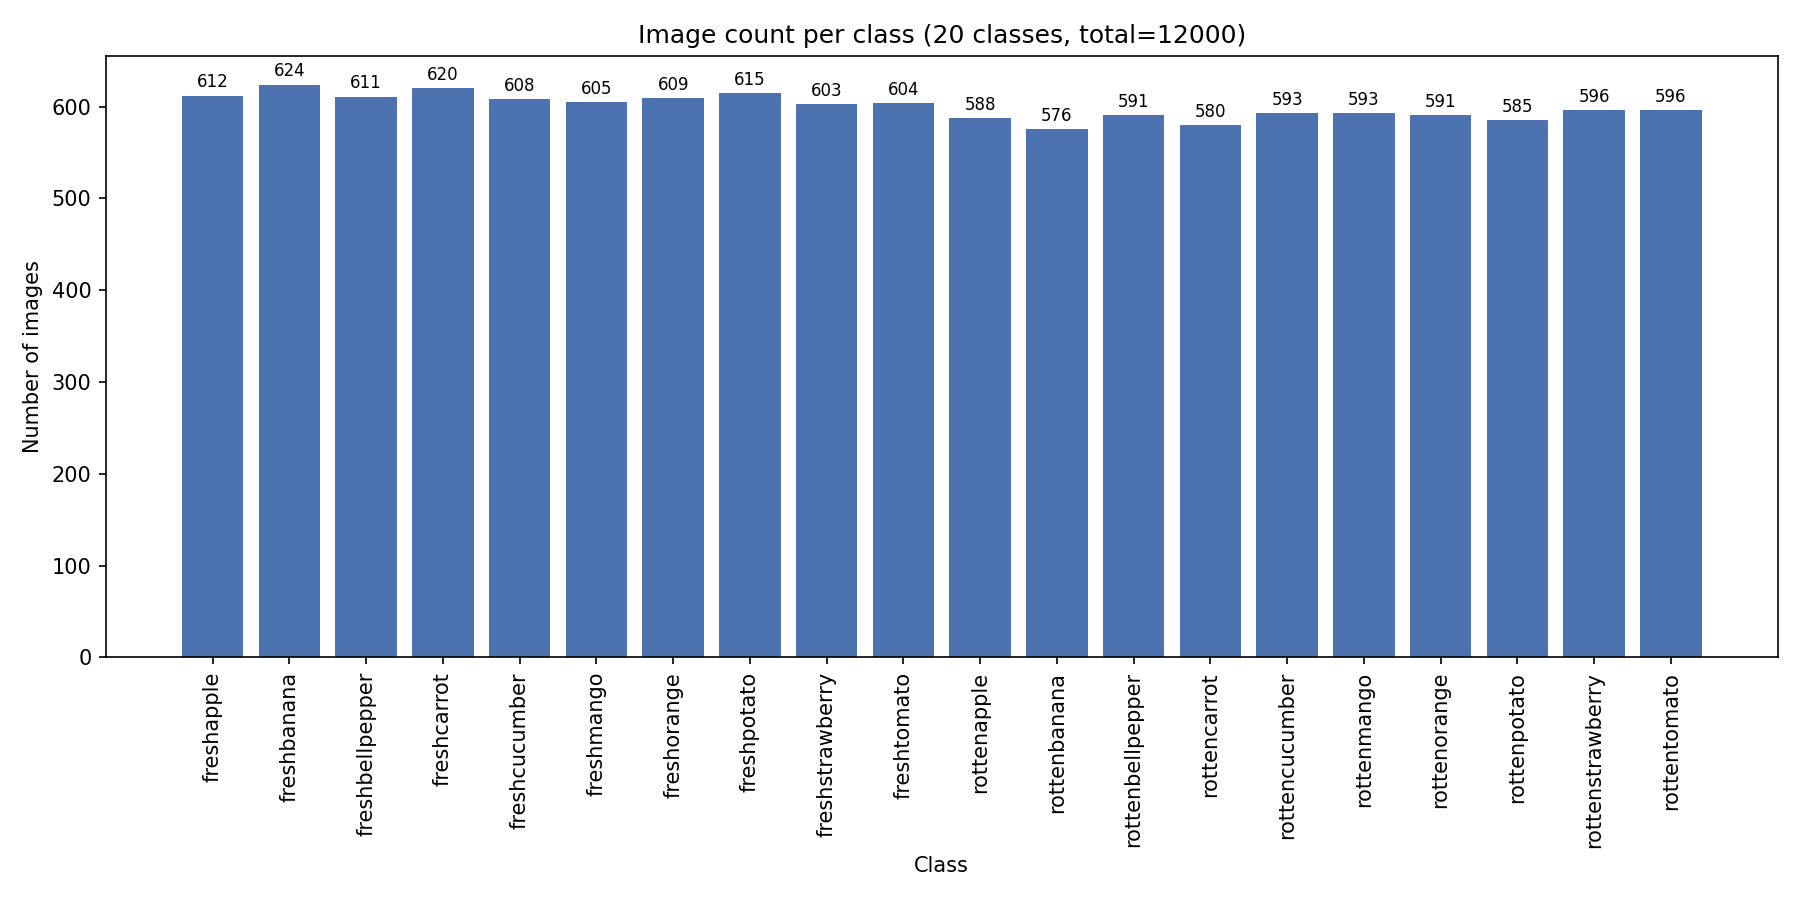

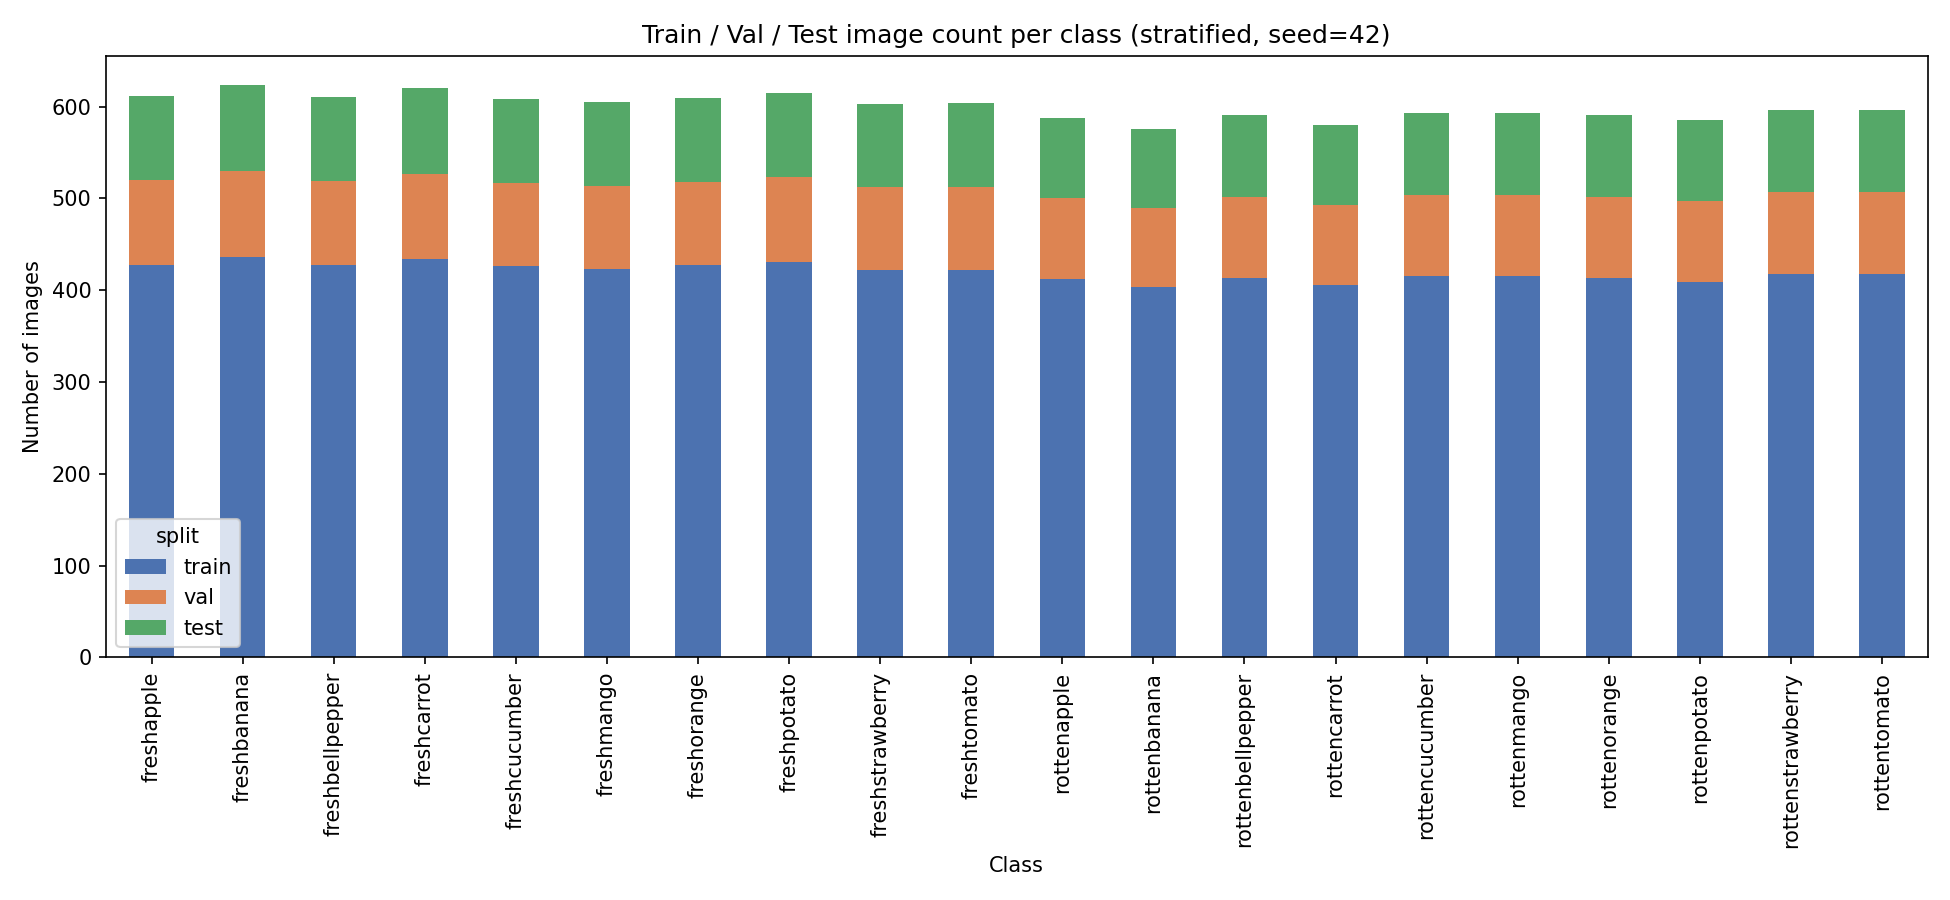


In [ ]:
recorded_quality = pd.DataFrame([{
    "total_images": 12000, "readable_images": 12000, "corrupt_images": 0,
    "num_classes": 20, "formats": "JPEG:9573, PNG:2409, WEBP:17, MPO:1",
    "width_min": 80, "width_max": 6183, "height_min": 95,
    "height_max": 4345, "unique_sizes": 1585,
}])
recorded_split_summary = split_by_class.reset_index()
display(recorded_quality)
display(recorded_split_summary.tail())


## 3. Feature alignment checks

Before classification, feature arrays are checked against the split created in the current run for shape, binary labels, and row order. These checks prevent accidental re-splitting and ensure that DenseNet and ResNeXt features refer to the same images before feature fusion.


In [ ]:
def validate_feature_rows(features, labels, expected_frame, expected_dimension, name):
    expected_labels = expected_frame["label"].map(binary_label).to_numpy(dtype=str)
    if features.ndim != 2 or features.shape != (len(expected_frame), expected_dimension):
        raise ValueError(f"{name}: expected {(len(expected_frame), expected_dimension)}, got {features.shape}")
    if not np.array_equal(np.asarray(labels).astype(str), expected_labels):
        raise ValueError(f"{name}: labels or row order do not match the current split")
    return {"name": name, "rows": len(features), "dimension": features.shape[1], "status": "OK"}



## 4. Frozen ResNet-18 feature baseline

ImageNet-pretrained ResNet-18 is used only as a frozen comparison baseline. Its classification head is removed, all parameters are frozen, and 512-dimensional no-augmentation features are extracted under `model.eval()` and `torch.no_grad()`. `StandardScaler` and PCA(95%) are fitted on training features only, followed by the same fixed RBF-SVM used for the main models.

**Recorded validation result.** The frozen ResNet-18 + PCA(95%) + SVM baseline retained 245 PCA components and achieved validation Macro-F1 0.9761.


## 5. Frozen feature extraction: ResNet-18, DenseNet-201 and ResNeXt-101

All backbones use torchvision default ImageNet weights, RGB 224×224 inputs and ImageNet normalization. Classification heads are replaced with identities, every parameter is frozen, and extraction runs under `eval()` / `torch.no_grad()`. Output dimensions are 512 (ResNet-18), 1,920 (DenseNet-201) and 2,048 (ResNeXt-101).

The historical DenseNet and ResNet-18 augmentation uses ±10° rotation, the committed ResNeXt augmentation script used ±15°. The notebook preserves this factual difference rather than silently claiming identical augmentation parameters. In every case augmentation is train-only, validation preprocessing is deterministic and shared with `no_aug`.


In [4]:
BACKBONE_SPECS = {
    "densenet201": {"dimension": 1920},
    "resnext101": {"dimension": 2048},
    "resnet18": {"dimension": 512},
}


def make_transform(case: str, split: str, backbone: str = "densenet201"):
    normalise = [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    if case == "aug" and split == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15 if backbone == "resnext101" else 10),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
            *normalise,
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        *normalise,
    ])


class FrozenFeatureDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, case: str, split: str, backbone: str):
        if split not in {"train", "val"}:
            raise ValueError("Frozen feature dataset permits train/val only")
        self.frame = frame.reset_index(drop=True)
        self.case = case
        self.split = split
        self.backbone = backbone
        self.transform = make_transform(case, split, backbone)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row["filepath"]) as image:
            image = image.convert("RGB")
            if self.case == "aug" and self.split == "train":
                with torch.random.fork_rng(devices=[]):
                    torch.manual_seed(SEED + index)
                    tensor = self.transform(image)
            else:
                tensor = self.transform(image)
        return tensor, str(row["binary_label"]), str(row["filepath"])


def build_frozen_backbone(name: str):
    if name == "densenet201":
        model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)
        model.classifier = nn.Identity()
    elif name == "resnext101":
        model = models.resnext101_32x8d(weights=models.ResNeXt101_32X8D_Weights.DEFAULT)
        model.fc = nn.Identity()
    elif name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Identity()
    else:
        raise ValueError(name)
    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.eval().to(DEVICE)


def feature_cache_paths(backbone: str, case: str, split: str):
    prefix = FEATURE_DIR / f"{backbone}_{case}_{split}"
    return {
        "X": prefix.with_name(prefix.name + "_features.npy"),
        "y": prefix.with_name(prefix.name + "_labels.npy"),
        "paths": prefix.with_name(prefix.name + "_paths.npy"),
    }


def extract_feature_split(model, backbone: str, case: str, split: str,
                          frame: pd.DataFrame, batch_size: int = 32):
    if split not in {"train", "val"}:
        raise ValueError("Feature extraction permits train/val only")
    cache = feature_cache_paths(backbone, case, split)
    if all(path.is_file() for path in cache.values()):
        print(f"Loading cached {backbone}/{case}/{split}")
        return {
            "X": np.load(cache["X"], mmap_mode="r"),
            "y": np.load(cache["y"]).astype(str),
            "paths": np.load(cache["paths"]).astype(str),
        }

    split_frame = frame[frame["split"].eq(split)].reset_index(drop=True)
    dataset = FrozenFeatureDataset(split_frame, case=case, split=split, backbone=backbone)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                        pin_memory=DEVICE.type == "cuda")
    feature_batches, labels, paths = [], [], []
    model.eval()
    with torch.no_grad():
        for images, batch_labels, batch_paths in tqdm(loader, desc=f"{backbone}/{case}/{split}"):
            values = model(images.to(DEVICE, non_blocking=True)).reshape(images.shape[0], -1)
            feature_batches.append(values.cpu().numpy().astype(np.float32, copy=False))
            labels.extend(batch_labels)
            paths.extend(batch_paths)
    X = np.concatenate(feature_batches, axis=0)
    y = np.asarray(labels, dtype=str)
    path_array = np.asarray(paths, dtype=str)
    expected_dimension = BACKBONE_SPECS[backbone]["dimension"]
    if X.shape != (len(split_frame), expected_dimension):
        raise RuntimeError(f"Unexpected {backbone} shape: {X.shape}")
    if not np.array_equal(y, split_frame["binary_label"].astype(str).to_numpy()):
        raise RuntimeError(f"{backbone}/{case}/{split} label order mismatch")
    if not np.array_equal(path_array, split_frame["filepath"].astype(str).to_numpy()):
        raise RuntimeError(f"{backbone}/{case}/{split} path order mismatch")
    np.save(cache["X"], X)
    np.save(cache["y"], y)
    np.save(cache["paths"], path_array)
    return {"X": X, "y": y, "paths": path_array}


In [5]:
FEATURE_SETS = {}

if RUN_FEATURE_EXTRACTION:
    if official_split is None:
        raise RuntimeError("Enable RUN_DATA_PREPARATION or provide official_split first")
    for backbone in ("densenet201", "resnext101"):
        print(f"\nPreparing {backbone}")
        backbone_model = build_frozen_backbone(backbone)
        no_aug_train = extract_feature_split(backbone_model, backbone, "no_aug", "train", official_split)
        no_aug_val = extract_feature_split(backbone_model, backbone, "no_aug", "val", official_split)
        aug_train = extract_feature_split(backbone_model, backbone, "aug", "train", official_split)
        # Validation preprocessing is identical in both cases: reuse the same validation features.
        FEATURE_SETS[(backbone, "no_aug")] = {"train": no_aug_train, "val": no_aug_val}
        FEATURE_SETS[(backbone, "aug")] = {"train": aug_train, "val": no_aug_val}
        del backbone_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    resnet_model = build_frozen_backbone("resnet18")
    resnet_train = extract_feature_split(resnet_model, "resnet18", "no_aug", "train", official_split)
    resnet_val = extract_feature_split(resnet_model, "resnet18", "no_aug", "val", official_split)
    FEATURE_SETS[("resnet18", "no_aug")] = {"train": resnet_train, "val": resnet_val}
    del resnet_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    for key, data in FEATURE_SETS.items():
        print(key, {split: values["X"].shape for split, values in data.items()})
else:
    recorded_feature_shapes = pd.DataFrame([
        {"feature": "DenseNet-201", "train_shape": "(8399, 1920)",
         "validation_shape": "(1801, 1920)", "raw_dimension": 1920},
        {"feature": "ResNeXt-101", "train_shape": "(8399, 2048)",
         "validation_shape": "(1801, 2048)", "raw_dimension": 2048},
        {"feature": "DenseNet + ResNeXt fusion", "train_shape": "(8399, 3968)",
         "validation_shape": "(1801, 3968)", "raw_dimension": 3968},
        {"feature": "Frozen ResNet-18", "train_shape": "(8399, 512)",
         "validation_shape": "(1801, 512)", "raw_dimension": 512},
    ])
    print("Recorded feature-array dimensions (full extraction code is defined above):")
    display(recorded_feature_shapes)


Recorded feature-array dimensions (full extraction code is defined above):


,feature,train_shape,validation_shape,raw_dimension
0,DenseNet-201,"(8399, 1920)","(1801, 1920)",1920
1,ResNeXt-101,"(8399, 2048)","(1801, 2048)",2048
2,DenseNet + ResNeXt fusion,"(8399, 3968)","(1801, 3968)",3968
3,Frozen ResNet-18,"(8399, 512)","(1801, 512)",512


## 6. Train-only scaling/PCA, classifiers and feature fusion

Cases A–F are: DenseNet without/with PCA, ResNeXt without/with PCA, and concatenated DenseNet+ResNeXt without/with PCA. `StandardScaler` and PCA are fitted on training features only, then reused for validation. PCA retains 95% variance. Fusion first standardizes each backbone block on train, then concatenates aligned rows.

Classifiers use fixed settings: RBF-SVM (`C=1`, `gamma='scale'`), Bagging (100 seed-42 decision trees), and LDA. Two historical LDA protocols exist and are kept separate:

- the Stage-4 A–F grid uses `solver='lsqr', shrinkage='auto'`.
- the dedicated DenseNet augmentation analysis uses `solver='svd'`.

The selected final model is SVM, so this historical LDA difference does not affect the winning configuration. Results from the two protocols are never relabelled as if they came from one universal LDA setting.


In [6]:
def make_classifier(name: str, lda_protocol: str = "stage4"):
    if name == "svm":
        return SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
    if name == "lda":
        if lda_protocol == "stage4":
            return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
        if lda_protocol == "densenet_analysis":
            return LinearDiscriminantAnalysis(solver="svd")
        raise ValueError(f"Unknown LDA protocol: {lda_protocol}")
    if name == "bagging":
        return BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )
    raise ValueError(name)


def build_pipeline(classifier_name: str, use_pca: bool, lda_protocol: str = "stage4"):
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=0.95, svd_solver="full", random_state=SEED)))
    steps.append(("classifier", make_classifier(classifier_name, lda_protocol)))
    return Pipeline(steps)


def fuse_feature_sets(dense: dict, resnext: dict):
    output = {}
    for split in ("train", "val"):
        dense_split, resnext_split = dense[split], resnext[split]
        if not np.array_equal(dense_split["y"], resnext_split["y"]):
            raise ValueError(f"Fusion label mismatch in {split}")
        if not np.array_equal(dense_split["paths"], resnext_split["paths"]):
            raise ValueError(f"Fusion path/order mismatch in {split}")
        X = np.concatenate([dense_split["X"], resnext_split["X"]], axis=1)
        if X.shape[1] != 3968:
            raise ValueError(f"Expected fusion dimension 3968, found {X.shape[1]}")
        output[split] = {"X": X, "y": dense_split["y"], "paths": dense_split["paths"]}
    return output


RUNS = []
PREDICTIONS = {}
CLASS_REPORTS = {}
CONFUSION_MATRICES = {}
FITTED_MODELS = {}
RUN_CONFIGS = {}


def run_validation_experiment(run_id: str, feature_data: dict, backbone: str,
                              feature_case: str, classifier_name: str, use_pca: bool):
    if set(feature_data) != {"train", "val"}:
        raise ValueError("Experiment data must contain train and val only")
    train, val = feature_data["train"], feature_data["val"]
    model = build_pipeline(classifier_name, use_pca)
    started = time.perf_counter()
    model.fit(train["X"], train["y"])
    predicted = model.predict(val["X"])
    elapsed = time.perf_counter() - started

    macro = precision_recall_fscore_support(
        val["y"], predicted, labels=CLASSES, average="macro", zero_division=0,
    )
    weighted = precision_recall_fscore_support(
        val["y"], predicted, labels=CLASSES, average="weighted", zero_division=0,
    )
    report = pd.DataFrame(classification_report(
        val["y"], predicted, labels=CLASSES, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )).transpose()
    matrix = confusion_matrix(val["y"], predicted, labels=CLASSES)
    pca_dimension = int(model.named_steps["pca"].n_components_) if use_pca else None
    row = {
        "run_id": run_id, "backbone": backbone, "feature_case": feature_case,
        "classifier": classifier_name.upper(), "pca": "PCA(95%)" if use_pca else "none",
        "split": "val", "accuracy": accuracy_score(val["y"], predicted),
        "macro_precision": macro[0], "macro_recall": macro[1], "macro_f1": macro[2],
        "weighted_precision": weighted[0], "weighted_recall": weighted[1],
        "weighted_f1": weighted[2], "raw_dim": train["X"].shape[1],
        "pca_dim": pca_dimension, "seconds": elapsed,
    }
    RUNS.append(row)
    PREDICTIONS[run_id] = {"truth": val["y"], "predicted": predicted, "paths": val["paths"]}
    CLASS_REPORTS[run_id] = report
    CONFUSION_MATRICES[run_id] = matrix
    FITTED_MODELS[run_id] = model
    RUN_CONFIGS[run_id] = {"backbone": backbone, "feature_case": feature_case}
    output_dim = pca_dimension or train["X"].shape[1]
    print(f"{run_id:<42} acc={row['accuracy']:.4f} macroF1={row['macro_f1']:.4f} "
          f"dim={row['raw_dim']}->{output_dim} time={elapsed:.1f}s")
    return row


def plot_confusion_matrix(matrix, title, axis=None):
    axis = axis or plt.subplots(figsize=(3.5, 3.1))[1]
    matrix = np.asarray(matrix)
    axis.imshow(matrix, cmap="Blues")
    axis.set_xticks([0, 1], CLASSES); axis.set_yticks([0, 1], CLASSES)
    axis.set_xlabel("predicted"); axis.set_ylabel("true"); axis.set_title(title, fontsize=9)
    axis.grid(False)
    for row in range(2):
        for column in range(2):
            axis.text(column, row, str(int(matrix[row, column])), ha="center", va="center",
                      color="white" if matrix[row, column] > matrix.max() / 2 else "black")
    return axis


def prediction_scores(model, features):
    predicted = model.predict(features).astype(str)
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        confidence = probabilities.max(axis=1)
        score = probabilities[:, list(model.classes_).index("fresh")] - probabilities[:, list(model.classes_).index("rotten")]
    else:
        score = np.asarray(model.decision_function(features), dtype=float).reshape(-1)
        confidence = np.abs(score)
    return predicted, score, confidence


def save_validation_artifacts(run_id, truth, predicted, paths, score, confidence, report, matrix):
    """Repository-equivalent prediction/report/confusion outputs for validation only."""
    output = pd.DataFrame({
        "filepath": paths, "true_binary": truth, "pred_binary": predicted,
        "correct": np.asarray(truth) == np.asarray(predicted),
        "decision_or_probability_score": score, "confidence_or_margin": confidence,
    })
    output.to_csv(RESULT_DIR / f"{run_id}_val_predictions.csv", index=False)
    output.loc[~output["correct"]].sort_values("confidence_or_margin").to_csv(
        RESULT_DIR / f"{run_id}_val_errors.csv", index=False,
    )
    report.to_csv(RESULT_DIR / f"{run_id}_val_classification_report.csv")
    pd.DataFrame(matrix, index=CLASSES, columns=CLASSES).to_csv(
        RESULT_DIR / f"{run_id}_val_confusion_matrix.csv"
    )


In [7]:
if RUN_VALIDATION_EXPERIMENTS:
    required = [(name, case) for name in ("densenet201", "resnext101") for case in ("no_aug", "aug")]
    if any(key not in FEATURE_SETS for key in required):
        raise RuntimeError("Run feature extraction first or load the committed feature arrays")
    FEATURE_SETS[("fusion", "no_aug")] = fuse_feature_sets(
        FEATURE_SETS[("densenet201", "no_aug")], FEATURE_SETS[("resnext101", "no_aug")]
    )
    FEATURE_SETS[("fusion", "aug")] = fuse_feature_sets(
        FEATURE_SETS[("densenet201", "aug")], FEATURE_SETS[("resnext101", "aug")]
    )

    # Complete validation grid: 2 augmentation cases × 3 feature types ×
    # 3 classifiers × 2 PCA settings = 36 validation experiments.
    for backbone in ("densenet201", "resnext101", "fusion"):
        for feature_case in ("no_aug", "aug"):
            data = FEATURE_SETS[(backbone, feature_case)]
            for classifier_name in ("svm", "lda", "bagging"):
                for use_pca in (False, True):
                    run_id = (
                        f"{backbone}_{feature_case}_{classifier_name}_"
                        f"{'pca95' if use_pca else 'nopca'}"
                    )
                    run_validation_experiment(
                        run_id, data, backbone, feature_case, classifier_name, use_pca,
                    )
    run_validation_experiment(
        "resnet18_frozen_no_aug_svm_pca95", FEATURE_SETS[("resnet18", "no_aug")],
        "resnet18_frozen", "no_aug", "svm", True,
    )
    validation_results = pd.DataFrame(RUNS)
else:
    # These are exact validation records already produced by the project. The full code path above
    # is the reproduction implementation; this branch makes its saved outputs visible to markers.
    recorded_stage4 = pd.DataFrame(json.loads(r'''[{"case":"A","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9783453637,"macro_precision":0.9783720758,"macro_recall":0.9783047987,"macro_f1":0.9783357191,"weighted_precision":0.9783492728,"weighted_recall":0.9783453637,"weighted_f1":0.9783446023,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":17.5144098001},{"case":"A","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9772348695,"macro_precision":0.9775635721,"macro_recall":0.9770427612,"macro_f1":0.9772158757,"weighted_precision":0.9773968389,"weighted_recall":0.9772348695,"weighted_f1":0.97722866,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":3.6308936998},{"case":"A","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9405885619,"macro_precision":0.9413454736,"macro_recall":0.9402314846,"macro_f1":0.9405086679,"weighted_precision":0.9410723611,"weighted_recall":0.9405885619,"weighted_f1":0.9405510359,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":144.3530999001},{"case":"B","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_precision":0.9772471338,"weighted_recall":0.9772348695,"weighted_f1":0.9772334651,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":11.7728217002},{"case":"B","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9644641866,"macro_precision":0.9652461405,"macro_recall":0.9641269242,"macro_f1":0.9644178385,"weighted_precision":0.9649580522,"weighted_recall":0.9644641866,"weighted_f1":0.9644427951,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":3.3058384},{"case":"B","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9156024431,"macro_precision":0.9164952638,"macro_recall":0.915181953,"macro_f1":0.9154710736,"weighted_precision":0.9162032197,"weighted_recall":0.9156024431,"weighted_f1":0.9155358332,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":40.8690106},{"case":"C","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9494725153,"macro_precision":0.9495759061,"macro_recall":0.9493562745,"macro_f1":0.949442339,"weighted_precision":0.9495076291,"weighted_recall":0.9494725153,"weighted_f1":0.9494663429,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":27.0965890002},{"case":"C","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9394780677,"macro_precision":0.9414229524,"macro_recall":0.9388830907,"macro_f1":0.9393332276,"weighted_precision":0.9409401796,"weighted_recall":0.9394780677,"weighted_f1":0.9393908345,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":3.6421196},{"case":"C","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9272626319,"macro_precision":0.927756849,"macro_recall":0.9269652872,"macro_f1":0.9271818126,"weighted_precision":0.9275533478,"weighted_recall":0.9272626319,"weighted_f1":0.9272289572,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":128.4478822001},{"case":"D","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9528039978,"macro_precision":0.9529945554,"macro_recall":0.9526458375,"macro_f1":0.9527704496,"weighted_precision":0.952885219,"weighted_recall":0.9528039978,"weighted_f1":0.9527949118,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":25.3142222001},{"case":"D","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9311493615,"macro_precision":0.9335241659,"macro_recall":0.9304756759,"macro_f1":0.9309572568,"weighted_precision":0.9329879197,"weighted_recall":0.9311493615,"weighted_f1":0.9310280322,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":5.7030817},{"case":"D","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8900610772,"macro_precision":0.890333344,"macro_recall":0.8898036502,"macro_f1":0.8899584518,"weighted_precision":0.8902062862,"weighted_recall":0.8900610772,"weighted_f1":0.8900237589,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":65.6567641001},{"case":"E","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9733481399,"macro_precision":0.9733332676,"macro_recall":0.9735107835,"macro_f1":0.9733451733,"weighted_precision":0.9735067784,"weighted_recall":0.9733481399,"weighted_f1":0.9733506381,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":33.2271325001},{"case":"E","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9716823987,"macro_precision":0.9720029393,"macro_recall":0.9714881926,"macro_f1":0.9716587722,"weighted_precision":0.9718403462,"weighted_recall":0.9716823987,"weighted_f1":0.9716746746,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":12.4105414001},{"case":"E","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.947806774,"macro_precision":0.948542251,"macro_recall":0.9474632183,"macro_f1":0.9477387003,"weighted_precision":0.9482712858,"weighted_recall":0.947806774,"weighted_f1":0.9477753554,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":220.0744959002},{"case":"F","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.973903387,"macro_precision":0.9738538876,"macro_recall":0.9739906784,"macro_f1":0.9738979471,"weighted_precision":0.9739557981,"weighted_recall":0.973903387,"weighted_f1":0.9739052701,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":713.3109454999},{"case":"F","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9655746807,"macro_precision":0.9657562066,"macro_recall":0.9654321399,"macro_f1":0.96555122,"weighted_precision":0.9656485217,"weighted_recall":0.9655746807,"weighted_f1":0.9655686908,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":21.1019043},{"case":"F","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8928373126,"macro_precision":0.8931210372,"macro_recall":0.8931530458,"macro_f1":0.8928371805,"weighted_precision":0.8934413714,"weighted_recall":0.8928373126,"weighted_f1":0.8928394931,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":117.3400864}]'''))
    recorded_densenet = pd.DataFrame(json.loads(r'''[{"case":"no_aug","classifier":"svm","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9877845641,"macro_precision":0.987802892,"macro_recall":0.9877583599,"macro_f1":0.9877794063,"weighted_f1":0.9877842853,"fit_seconds":4.7478094,"predict_seconds":1.6840527,"total_seconds":6.4318621,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"lda","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9700166574,"macro_precision":0.9704278228,"macro_recall":0.9697894384,"macro_f1":0.9699886687,"weighted_f1":0.9700064797,"fit_seconds":0.5254192,"predict_seconds":0.0024733,"total_seconds":0.5278925,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9439200444,"macro_precision":0.9439289063,"macro_recall":0.9438664732,"macro_f1":0.9438950674,"weighted_f1":0.9439180725,"fit_seconds":61.4783564,"predict_seconds":0.4618805,"total_seconds":61.9402369,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"svm","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_f1":0.9772334651,"fit_seconds":5.9411231,"predict_seconds":2.2465513,"total_seconds":8.1876744,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"lda","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9677956691,"macro_precision":0.9682704426,"macro_recall":0.9675460218,"macro_f1":0.9677633788,"weighted_f1":0.9677832062,"fit_seconds":0.5975146,"predict_seconds":0.0027813,"total_seconds":0.6002959,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9161576902,"macro_precision":0.9171903708,"macro_recall":0.9157050262,"macro_f1":0.9160159043,"weighted_f1":0.9160829652,"fit_seconds":48.823112,"predict_seconds":0.4644061,"total_seconds":49.2875181,"n_train":8399,"n_val":1801,"seed":42}]'''))
    recorded_resnet_frozen = pd.DataFrame(json.loads(r'''[{"model":"resnet18","case":"no_aug_baseline","classifier":"svm","pca_target":"0.95_variance","pca_components":245,"accuracy":0.9761243753,"macro_precision":0.976178871,"macro_recall":0.9760613821,"macro_f1":0.9761125922,"weighted_f1":0.9761229025,"fit_seconds":1.3050859,"predict_seconds":0.7899296,"total_seconds":2.0950155,"n_train":8399,"n_val":1801,"seed":42}]'''))
    case_to_backbone = {
        "A": "densenet201", "B": "densenet201", "C": "resnext101",
        "D": "resnext101", "E": "fusion", "F": "fusion",
    }
    recorded_rows = []
    for _, row in recorded_stage4.iterrows():
        pca_used = pd.notna(row["pca_feature_dim"])
        recorded_rows.append({
            "run_id": f"{case_to_backbone[row['case']]}_aug_{row['classifier']}_"
                      f"{'pca95' if pca_used else 'nopca'}",
            "backbone": case_to_backbone[row["case"]], "feature_case": "aug",
            "classifier": str(row["classifier"]).upper(),
            "pca": "PCA(95%)" if pca_used else "none", "split": "val",
            "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
            "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
            "weighted_precision": row["weighted_precision"],
            "weighted_recall": row["weighted_recall"], "weighted_f1": row["weighted_f1"],
            "raw_dim": int(row["raw_feature_dim"]),
            "pca_dim": row["pca_feature_dim"], "seconds": row["seconds"],
        })
    for _, row in recorded_densenet[recorded_densenet["case"].eq("no_aug")].iterrows():
        recorded_rows.append({
            "run_id": f"densenet201_no_aug_{row['classifier']}_pca95",
            "backbone": "densenet201", "feature_case": "no_aug",
            "classifier": str(row["classifier"]).upper(), "pca": "PCA(95%)", "split": "val",
            "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
            "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
            "weighted_precision": np.nan, "weighted_recall": np.nan,
            "weighted_f1": row["weighted_f1"], "raw_dim": 1920,
            "pca_dim": int(row["pca_components"]), "seconds": row["total_seconds"],
        })
    row = recorded_resnet_frozen.iloc[0]
    recorded_rows.append({
        "run_id": "resnet18_frozen_no_aug_svm_pca95", "backbone": "resnet18_frozen",
        "feature_case": "no_aug", "classifier": "SVM", "pca": "PCA(95%)", "split": "val",
        "accuracy": row["accuracy"], "macro_precision": row["macro_precision"],
        "macro_recall": row["macro_recall"], "macro_f1": row["macro_f1"],
        "weighted_precision": np.nan, "weighted_recall": np.nan,
        "weighted_f1": row["weighted_f1"], "raw_dim": 512,
        "pca_dim": int(row["pca_components"]), "seconds": row["total_seconds"],
    })
    validation_results = pd.DataFrame(recorded_rows)
    print("Displaying embedded real validation outputs; no model was fitted in submission mode.")

validation_results = validation_results.sort_values(
    ["macro_f1", "accuracy", "seconds"], ascending=[False, False, True]
).reset_index(drop=True)
validation_results.index += 1
validation_results.index.name = "validation_rank"
display(validation_results)
validation_results.to_csv(RESULT_DIR / "person5_validation_results.csv", index=True)


Displaying embedded real validation outputs; no model was fitted in submission mode.


,run_id,backbone,feature_case,classifier,pca,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,raw_dim,pca_dim,seconds
validation_rank,,,,,,,,,,,,,,,,
1,densenet201_no_aug_svm_pca95,densenet201,no_aug,SVM,PCA(95%),val,0.9878,0.9878,0.9878,0.9878,NaN,NaN,0.9878,1920,690.0,6.4319
2,densenet201_aug_svm_nopca,densenet201,aug,SVM,none,val,0.9783,0.9784,0.9783,0.9783,0.9783,0.9783,0.9783,1920,NaN,17.5144
3,densenet201_aug_svm_pca95,densenet201,aug,SVM,PCA(95%),val,0.9772,0.9773,0.9772,0.9772,0.9772,0.9772,0.9772,1920,738.0,11.7728
4,densenet201_aug_lda_nopca,densenet201,aug,LDA,none,val,0.9772,0.9776,0.9770,0.9772,0.9774,0.9772,0.9772,1920,NaN,3.6309
5,resnet18_frozen_no_aug_svm_pca95,resnet18_frozen,no_aug,SVM,PCA(95%),val,0.9761,0.9762,0.9761,0.9761,NaN,NaN,0.9761,512,245.0,2.0950
6,fusion_aug_svm_pca95,fusion,aug,SVM,PCA(95%),val,0.9739,0.9739,0.9740,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
7,fusion_aug_svm_nopca,fusion,aug,SVM,none,val,0.9733,0.9733,0.9735,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
8,fusion_aug_lda_nopca,fusion,aug,LDA,none,val,0.9717,0.9720,0.9715,0.9717,0.9718,0.9717,0.9717,3968,NaN,12.4105
9,densenet201_no_aug_lda_pca95,densenet201,no_aug,LDA,PCA(95%),val,0.9700,0.9704,0.9698,0.9700,NaN,NaN,0.9700,1920,690.0,0.5279


### 6.1 Dedicated DenseNet augmentation analysis

The repository also contains a validation-only DenseNet analysis that compares `no_aug` and `aug` after train-only StandardScaler + PCA(95%). It fits SVM, SVD-LDA and Bagging, records fit/predict time, writes one prediction and error CSV per configuration, writes per-class reports, and generates six confusion matrices plus a 2×3 comparison figure. No test array is loaded by this analysis.


In [ ]:
def run_densenet_augmentation_analysis(feature_sets):
    rows, artifacts = [], {}
    for case in ("no_aug", "aug"):
        data = feature_sets[("densenet201", case)]
        train, val = data["train"], data["val"]
        for classifier_name in ("svm", "lda", "bagging"):
            pipeline = build_pipeline(
                classifier_name, use_pca=True, lda_protocol="densenet_analysis"
            )
            started = time.perf_counter(); pipeline.fit(train["X"], train["y"])
            fit_seconds = time.perf_counter() - started
            started = time.perf_counter()
            predicted, score, confidence = prediction_scores(pipeline, val["X"])
            predict_seconds = time.perf_counter() - started
            macro = precision_recall_fscore_support(
                val["y"], predicted, labels=CLASSES, average="macro", zero_division=0,
            )
            weighted = precision_recall_fscore_support(
                val["y"], predicted, labels=CLASSES, average="weighted", zero_division=0,
            )
            report = pd.DataFrame(classification_report(
                val["y"], predicted, labels=CLASSES, target_names=CLASSES,
                output_dict=True, zero_division=0,
            )).T
            matrix = confusion_matrix(val["y"], predicted, labels=CLASSES)
            run_id = f"densenet201_{case}_{classifier_name}"
            save_validation_artifacts(
                run_id, val["y"], predicted, val["paths"], score, confidence, report, matrix,
            )
            rows.append({
                "case": case, "classifier": classifier_name,
                "pca_components": int(pipeline.named_steps["pca"].n_components_),
                "accuracy": accuracy_score(val["y"], predicted),
                "macro_precision": macro[0], "macro_recall": macro[1],
                "macro_f1": macro[2], "weighted_f1": weighted[2],
                "fit_seconds": fit_seconds, "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
            })
            artifacts[(case, classifier_name)] = {"report": report, "matrix": matrix}
    return pd.DataFrame(rows), artifacts


if RUN_VALIDATION_EXPERIMENTS:
    densenet_augmentation_metrics, densenet_augmentation_artifacts = (
        run_densenet_augmentation_analysis(FEATURE_SETS)
    )


## 7. Committed validation results

The following three small tables are embedded numeric records from the group repository at the
time this notebook was assembled. They preserve existing results if a marker reads the notebook
without rerunning the expensive GPU stages. They are not loaded from external files and are not
used to override a newly executed validation run.

- `recorded_stage4`: augmented DenseNet/ResNeXt/fusion A–F grid.
- `recorded_densenet`: DenseNet PCA(95%) no-augmentation/augmentation comparison.
- `recorded_resnet_frozen`: frozen ResNet-18 validation reference.

No test values appear in these validation tables.


In [8]:
recorded_stage4 = pd.DataFrame(json.loads(r'''[{"case":"A","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9783453637,"macro_precision":0.9783720758,"macro_recall":0.9783047987,"macro_f1":0.9783357191,"weighted_precision":0.9783492728,"weighted_recall":0.9783453637,"weighted_f1":0.9783446023,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":17.5144098001},{"case":"A","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9772348695,"macro_precision":0.9775635721,"macro_recall":0.9770427612,"macro_f1":0.9772158757,"weighted_precision":0.9773968389,"weighted_recall":0.9772348695,"weighted_f1":0.97722866,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":3.6308936998},{"case":"A","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9405885619,"macro_precision":0.9413454736,"macro_recall":0.9402314846,"macro_f1":0.9405086679,"weighted_precision":0.9410723611,"weighted_recall":0.9405885619,"weighted_f1":0.9405510359,"raw_feature_dim":1920,"pca_feature_dim":null,"seconds":144.3530999001},{"case":"B","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_precision":0.9772471338,"weighted_recall":0.9772348695,"weighted_f1":0.9772334651,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":11.7728217002},{"case":"B","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9644641866,"macro_precision":0.9652461405,"macro_recall":0.9641269242,"macro_f1":0.9644178385,"weighted_precision":0.9649580522,"weighted_recall":0.9644641866,"weighted_f1":0.9644427951,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":3.3058384},{"case":"B","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9156024431,"macro_precision":0.9164952638,"macro_recall":0.915181953,"macro_f1":0.9154710736,"weighted_precision":0.9162032197,"weighted_recall":0.9156024431,"weighted_f1":0.9155358332,"raw_feature_dim":1920,"pca_feature_dim":738.0,"seconds":40.8690106},{"case":"C","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9494725153,"macro_precision":0.9495759061,"macro_recall":0.9493562745,"macro_f1":0.949442339,"weighted_precision":0.9495076291,"weighted_recall":0.9494725153,"weighted_f1":0.9494663429,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":27.0965890002},{"case":"C","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9394780677,"macro_precision":0.9414229524,"macro_recall":0.9388830907,"macro_f1":0.9393332276,"weighted_precision":0.9409401796,"weighted_recall":0.9394780677,"weighted_f1":0.9393908345,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":3.6421196},{"case":"C","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.9272626319,"macro_precision":0.927756849,"macro_recall":0.9269652872,"macro_f1":0.9271818126,"weighted_precision":0.9275533478,"weighted_recall":0.9272626319,"weighted_f1":0.9272289572,"raw_feature_dim":2048,"pca_feature_dim":null,"seconds":128.4478822001},{"case":"D","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9528039978,"macro_precision":0.9529945554,"macro_recall":0.9526458375,"macro_f1":0.9527704496,"weighted_precision":0.952885219,"weighted_recall":0.9528039978,"weighted_f1":0.9527949118,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":25.3142222001},{"case":"D","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9311493615,"macro_precision":0.9335241659,"macro_recall":0.9304756759,"macro_f1":0.9309572568,"weighted_precision":0.9329879197,"weighted_recall":0.9311493615,"weighted_f1":0.9310280322,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":5.7030817},{"case":"D","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8900610772,"macro_precision":0.890333344,"macro_recall":0.8898036502,"macro_f1":0.8899584518,"weighted_precision":0.8902062862,"weighted_recall":0.8900610772,"weighted_f1":0.8900237589,"raw_feature_dim":2048,"pca_feature_dim":1316.0,"seconds":65.6567641001},{"case":"E","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.9733481399,"macro_precision":0.9733332676,"macro_recall":0.9735107835,"macro_f1":0.9733451733,"weighted_precision":0.9735067784,"weighted_recall":0.9733481399,"weighted_f1":0.9733506381,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":33.2271325001},{"case":"E","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9716823987,"macro_precision":0.9720029393,"macro_recall":0.9714881926,"macro_f1":0.9716587722,"weighted_precision":0.9718403462,"weighted_recall":0.9716823987,"weighted_f1":0.9716746746,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":12.4105414001},{"case":"E","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.947806774,"macro_precision":0.948542251,"macro_recall":0.9474632183,"macro_f1":0.9477387003,"weighted_precision":0.9482712858,"weighted_recall":0.947806774,"weighted_f1":0.9477753554,"raw_feature_dim":3968,"pca_feature_dim":null,"seconds":220.0744959002},{"case":"F","feature_case":"aug","classifier":"svm","split":"val","accuracy":0.973903387,"macro_precision":0.9738538876,"macro_recall":0.9739906784,"macro_f1":0.9738979471,"weighted_precision":0.9739557981,"weighted_recall":0.973903387,"weighted_f1":0.9739052701,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":713.3109454999},{"case":"F","feature_case":"aug","classifier":"lda","split":"val","accuracy":0.9655746807,"macro_precision":0.9657562066,"macro_recall":0.9654321399,"macro_f1":0.96555122,"weighted_precision":0.9656485217,"weighted_recall":0.9655746807,"weighted_f1":0.9655686908,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":21.1019043},{"case":"F","feature_case":"aug","classifier":"bagging","split":"val","accuracy":0.8928373126,"macro_precision":0.8931210372,"macro_recall":0.8931530458,"macro_f1":0.8928371805,"weighted_precision":0.8934413714,"weighted_recall":0.8928373126,"weighted_f1":0.8928394931,"raw_feature_dim":3968,"pca_feature_dim":1796.0,"seconds":117.3400864}]'''))
recorded_densenet = pd.DataFrame(json.loads(r'''[{"case":"no_aug","classifier":"svm","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9877845641,"macro_precision":0.987802892,"macro_recall":0.9877583599,"macro_f1":0.9877794063,"weighted_f1":0.9877842853,"fit_seconds":4.7478094,"predict_seconds":1.6840527,"total_seconds":6.4318621,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"lda","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9700166574,"macro_precision":0.9704278228,"macro_recall":0.9697894384,"macro_f1":0.9699886687,"weighted_f1":0.9700064797,"fit_seconds":0.5254192,"predict_seconds":0.0024733,"total_seconds":0.5278925,"n_train":8399,"n_val":1801,"seed":42},{"case":"no_aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":690,"accuracy":0.9439200444,"macro_precision":0.9439289063,"macro_recall":0.9438664732,"macro_f1":0.9438950674,"weighted_f1":0.9439180725,"fit_seconds":61.4783564,"predict_seconds":0.4618805,"total_seconds":61.9402369,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"svm","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9772348695,"macro_precision":0.9772900589,"macro_recall":0.9771722959,"macro_f1":0.9772236344,"weighted_f1":0.9772334651,"fit_seconds":5.9411231,"predict_seconds":2.2465513,"total_seconds":8.1876744,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"lda","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9677956691,"macro_precision":0.9682704426,"macro_recall":0.9675460218,"macro_f1":0.9677633788,"weighted_f1":0.9677832062,"fit_seconds":0.5975146,"predict_seconds":0.0027813,"total_seconds":0.6002959,"n_train":8399,"n_val":1801,"seed":42},{"case":"aug","classifier":"bagging","pca_target":"0.95_variance","pca_components":738,"accuracy":0.9161576902,"macro_precision":0.9171903708,"macro_recall":0.9157050262,"macro_f1":0.9160159043,"weighted_f1":0.9160829652,"fit_seconds":48.823112,"predict_seconds":0.4644061,"total_seconds":49.2875181,"n_train":8399,"n_val":1801,"seed":42}]'''))
recorded_resnet_frozen = pd.DataFrame(json.loads(r'''[{"model":"resnet18","case":"no_aug_baseline","classifier":"svm","pca_target":"0.95_variance","pca_components":245,"accuracy":0.9761243753,"macro_precision":0.976178871,"macro_recall":0.9760613821,"macro_f1":0.9761125922,"weighted_f1":0.9761229025,"fit_seconds":1.3050859,"predict_seconds":0.7899296,"total_seconds":2.0950155,"n_train":8399,"n_val":1801,"seed":42}]'''))

assert recorded_stage4["split"].astype(str).str.lower().eq("val").all()
display(recorded_stage4.sort_values("macro_f1", ascending=False).reset_index(drop=True))
display(recorded_densenet.sort_values("macro_f1", ascending=False).reset_index(drop=True))
display(recorded_resnet_frozen)

,case,feature_case,classifier,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,raw_feature_dim,pca_feature_dim,seconds
0,A,aug,svm,val,0.9783,0.9784,0.9783,0.9783,0.9783,0.9783,0.9783,1920,NaN,17.5144
1,B,aug,svm,val,0.9772,0.9773,0.9772,0.9772,0.9772,0.9772,0.9772,1920,738.0,11.7728
2,A,aug,lda,val,0.9772,0.9776,0.9770,0.9772,0.9774,0.9772,0.9772,1920,NaN,3.6309
3,F,aug,svm,val,0.9739,0.9739,0.9740,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
4,E,aug,svm,val,0.9733,0.9733,0.9735,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
5,E,aug,lda,val,0.9717,0.9720,0.9715,0.9717,0.9718,0.9717,0.9717,3968,NaN,12.4105
6,F,aug,lda,val,0.9656,0.9658,0.9654,0.9656,0.9656,0.9656,0.9656,3968,1796.0,21.1019
7,B,aug,lda,val,0.9645,0.9652,0.9641,0.9644,0.9650,0.9645,0.9644,1920,738.0,3.3058
8,D,aug,svm,val,0.9528,0.9530,0.9526,0.9528,0.9529,0.9528,0.9528,2048,1316.0,25.3142
9,C,aug,svm,val,0.9495,0.9496,0.9494,0.9494,0.9495,0.9495,0.9495,2048,NaN,27.0966


,case,classifier,pca_target,pca_components,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds,predict_seconds,total_seconds,n_train,n_val,seed
0,no_aug,svm,0.95_variance,690,0.9878,0.9878,0.9878,0.9878,0.9878,4.7478,1.6841,6.4319,8399,1801,42
1,aug,svm,0.95_variance,738,0.9772,0.9773,0.9772,0.9772,0.9772,5.9411,2.2466,8.1877,8399,1801,42
2,no_aug,lda,0.95_variance,690,0.9700,0.9704,0.9698,0.9700,0.9700,0.5254,0.0025,0.5279,8399,1801,42
3,aug,lda,0.95_variance,738,0.9678,0.9683,0.9675,0.9678,0.9678,0.5975,0.0028,0.6003,8399,1801,42
4,no_aug,bagging,0.95_variance,690,0.9439,0.9439,0.9439,0.9439,0.9439,61.4784,0.4619,61.9402,8399,1801,42
5,aug,bagging,0.95_variance,738,0.9162,0.9172,0.9157,0.9160,0.9161,48.8231,0.4644,49.2875,8399,1801,42


,model,case,classifier,pca_target,pca_components,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds,predict_seconds,total_seconds,n_train,n_val,seed
0,resnet18,no_aug_baseline,svm,0.95_variance,245,0.9761,0.9762,0.9761,0.9761,0.9761,1.3051,0.7899,2.095,8399,1801,42


## 8. Focused classifier comparison

This is the full plotting logic corresponding to group member 4's report Results figure. It uses
only the embedded validation tables, displays the chart directly, and saves a reproducible copy as
`report_results_pca95_classifier_comparison.png` in the notebook results directory.


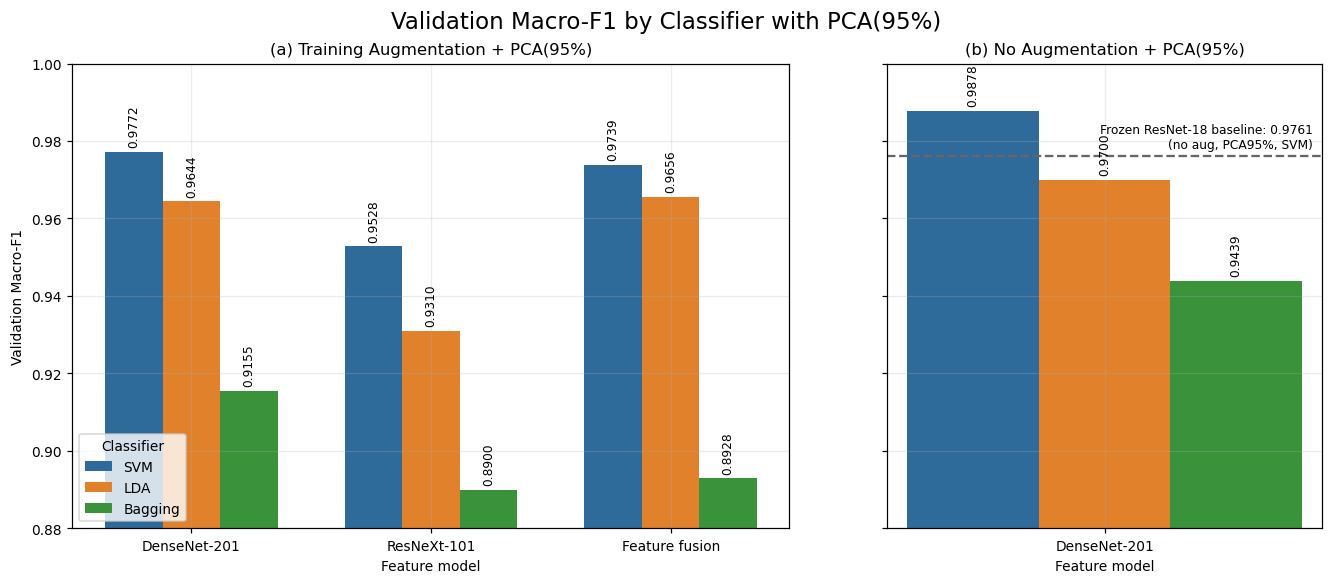

In [9]:
model_cases = {"DenseNet-201": "B", "ResNeXt-101": "D", "Feature fusion": "F"}
classifier_names = ["svm", "lda", "bagging"]
classifier_labels = {"svm": "SVM", "lda": "LDA", "bagging": "Bagging"}
colours = {"svm": "#2F6B9A", "lda": "#E1812C", "bagging": "#3A923A"}


def select_one(frame, mask, description):
    rows = frame.loc[mask]
    if len(rows) != 1:
        raise ValueError(f"Expected one {description} row, found {len(rows)}")
    return rows.iloc[0]


augmented_rows = []
for model_name, case_name in model_cases.items():
    for classifier_name in classifier_names:
        row = select_one(
            recorded_stage4,
            recorded_stage4["case"].astype(str).str.upper().eq(case_name)
            & recorded_stage4["feature_case"].astype(str).str.lower().eq("aug")
            & recorded_stage4["classifier"].astype(str).str.lower().eq(classifier_name)
            & recorded_stage4["pca_feature_dim"].notna(),
            f"{model_name}/{classifier_name}/PCA95 validation",
        )
        augmented_rows.append({"model": model_name, "classifier": classifier_name,
                               "macro_f1": float(row["macro_f1"])})
augmented_plot = pd.DataFrame(augmented_rows)

no_aug_rows = []
for classifier_name in classifier_names:
    row = select_one(
        recorded_densenet,
        recorded_densenet["case"].astype(str).str.lower().eq("no_aug")
        & recorded_densenet["classifier"].astype(str).str.lower().eq(classifier_name)
        & recorded_densenet["pca_target"].astype(str).eq("0.95_variance"),
        f"DenseNet no_aug/{classifier_name}/PCA95 validation",
    )
    no_aug_rows.append({"classifier": classifier_name, "macro_f1": float(row["macro_f1"])})
no_aug_plot = pd.DataFrame(no_aug_rows)

baseline_macro_f1 = float(recorded_resnet_frozen.iloc[0]["macro_f1"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, layout="constrained",
                         gridspec_kw={"width_ratios": [1.65, 1.0], "wspace": 0.14})
bar_width = 0.24
model_names = list(model_cases)
left_x = np.arange(len(model_names))
for index, classifier_name in enumerate(classifier_names):
    values = [float(augmented_plot[
        augmented_plot["model"].eq(model_name)
        & augmented_plot["classifier"].eq(classifier_name)
    ].iloc[0]["macro_f1"]) for model_name in model_names]
    bars = axes[0].bar(left_x + (index - 1) * bar_width, values, bar_width,
                       color=colours[classifier_name], label=classifier_labels[classifier_name])
    axes[0].bar_label(bars, labels=[f"{value:.4f}" for value in values],
                      padding=3, fontsize=8, rotation=90)
for index, classifier_name in enumerate(classifier_names):
    value = float(no_aug_plot[no_aug_plot["classifier"].eq(classifier_name)].iloc[0]["macro_f1"])
    bars = axes[1].bar([(index - 1) * bar_width], [value], bar_width,
                       color=colours[classifier_name])
    axes[1].bar_label(bars, labels=[f"{value:.4f}"], padding=3, fontsize=8, rotation=90)
axes[1].axhline(baseline_macro_f1, color="#666666", linestyle="--", linewidth=1.5)
axes[1].text(0.98, baseline_macro_f1 + 0.0012,
             f"Frozen ResNet-18 baseline: {baseline_macro_f1:.4f}\n(no aug, PCA95%, SVM)",
             transform=axes[1].get_yaxis_transform(), ha="right", va="bottom", fontsize=8)
axes[0].set_title("(a) Training Augmentation + PCA(95%)")
axes[1].set_title("(b) No Augmentation + PCA(95%)")
axes[0].set_xticks(left_x); axes[0].set_xticklabels(model_names)
axes[1].set_xticks([0]); axes[1].set_xticklabels(["DenseNet-201"])
axes[0].set_ylabel("Validation Macro-F1")
for axis in axes:
    axis.set_xlabel("Feature model"); axis.set_ylim(0.88, 1.0); axis.grid(axis="y", alpha=0.25)
axes[0].legend(title="Classifier", loc="lower left")
fig.suptitle("Validation Macro-F1 by Classifier with PCA(95%)", fontsize=15)
report_figure_path = RESULT_DIR / "report_results_pca95_classifier_comparison.png"
fig.savefig(report_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved report figure: {report_figure_path}")

## 9. Full validation metrics, per-class results and confusion matrices

The live results below include all required aggregate metrics. Per-class Precision/Recall/F1 and
confusion matrices are generated from validation predictions. The displayed major configurations
are the validation-best run for each DenseNet, ResNeXt and fusion augmentation case, plus the
frozen ResNet-18 reference. Full results for every run remain in `CLASS_REPORTS` and
`CONFUSION_MATRICES`.


,backbone,feature_case,classifier,pca,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_dim,pca_dim,seconds
validation_rank,,,,,,,,,,,,
1,densenet201,no_aug,SVM,PCA(95%),0.9878,0.9878,0.9878,0.9878,0.9878,1920,690.0,6.4319
2,densenet201,aug,SVM,none,0.9783,0.9784,0.9783,0.9783,0.9783,1920,NaN,17.5144
3,densenet201,aug,SVM,PCA(95%),0.9772,0.9773,0.9772,0.9772,0.9772,1920,738.0,11.7728
4,densenet201,aug,LDA,none,0.9772,0.9776,0.9770,0.9772,0.9772,1920,NaN,3.6309
5,resnet18_frozen,no_aug,SVM,PCA(95%),0.9761,0.9762,0.9761,0.9761,0.9761,512,245.0,2.0950
6,fusion,aug,SVM,PCA(95%),0.9739,0.9739,0.9740,0.9739,0.9739,3968,1796.0,713.3109
7,fusion,aug,SVM,none,0.9733,0.9733,0.9735,0.9733,0.9734,3968,NaN,33.2271
8,fusion,aug,LDA,none,0.9717,0.9720,0.9715,0.9717,0.9717,3968,NaN,12.4105
9,densenet201,no_aug,LDA,PCA(95%),0.9700,0.9704,0.9698,0.9700,0.9700,1920,690.0,0.5279


Complete recorded Stage-4 validation per-class metrics:


,case,classifier,class,precision,recall,f1-score,support
0,A,svm,fresh,0.9772,0.9804,0.9788,918.0
1,A,svm,rotten,0.9795,0.9762,0.9779,883.0
2,A,lda,fresh,0.9690,0.9869,0.9779,918.0
3,A,lda,rotten,0.9861,0.9672,0.9766,883.0
4,A,bagging,fresh,0.9273,0.9586,0.9427,918.0
5,A,bagging,rotten,0.9554,0.9219,0.9383,883.0
6,B,svm,fresh,0.9751,0.9804,0.9777,918.0
7,B,svm,rotten,0.9795,0.9740,0.9767,883.0
8,B,lda,fresh,0.9504,0.9815,0.9657,918.0
9,B,lda,rotten,0.9801,0.9468,0.9631,883.0


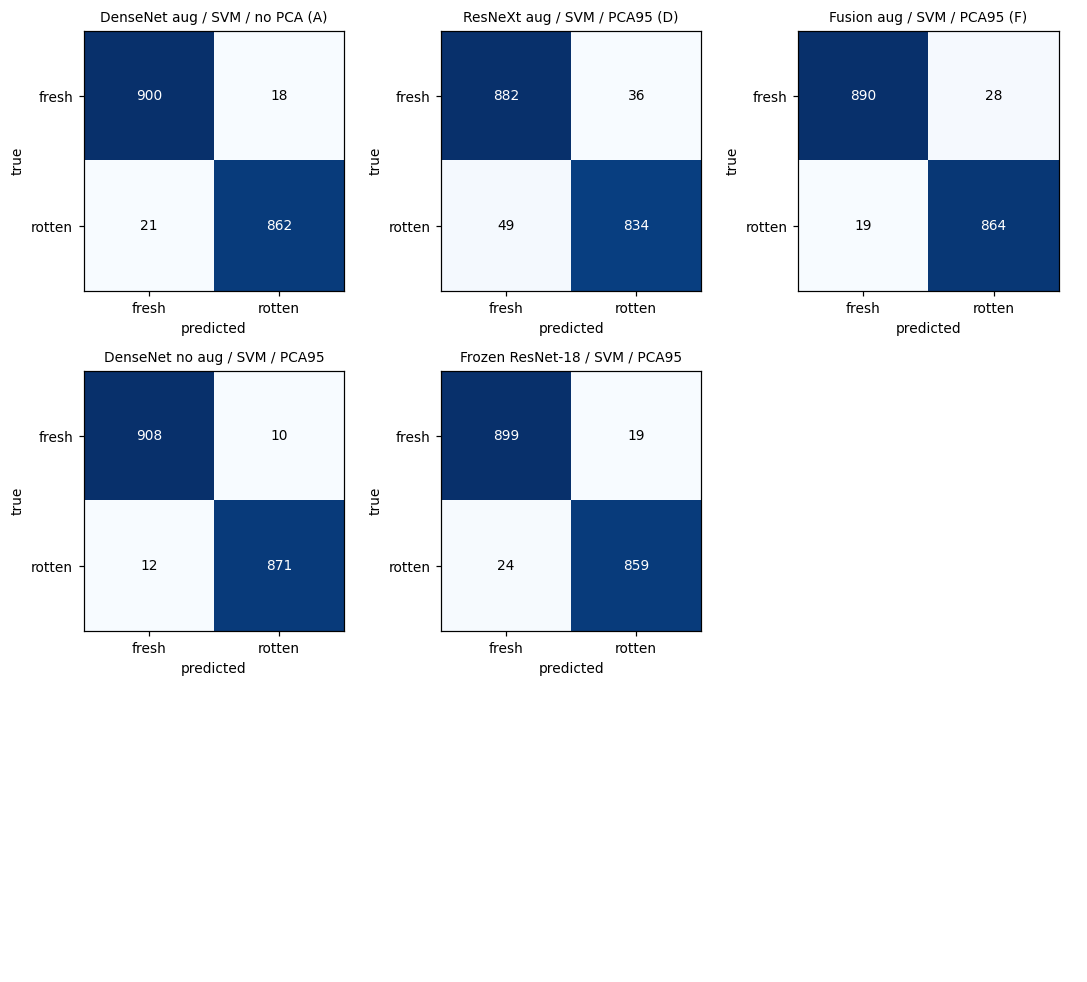

In [10]:
summary_columns = [
    "backbone", "feature_case", "classifier", "pca", "accuracy",
    "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
    "raw_dim", "pca_dim", "seconds",
]
display(validation_results[summary_columns])

if RUN_FULL_REPRODUCTION:
    major_run_ids = []
    for backbone in ("densenet201", "resnext101", "fusion"):
        for feature_case in ("no_aug", "aug"):
            subset = validation_results[
                validation_results["backbone"].eq(backbone)
                & validation_results["feature_case"].eq(feature_case)
            ]
            major_run_ids.append(str(subset.iloc[0]["run_id"]))
    major_run_ids.append("resnet18_frozen_no_aug_svm_pca95")

    per_class_rows = []
    for run_id in major_run_ids:
        report = CLASS_REPORTS[run_id]
        for class_name in CLASSES:
            per_class_rows.append({
                "run_id": run_id, "class": class_name,
                "precision": report.loc[class_name, "precision"],
                "recall": report.loc[class_name, "recall"],
                "f1": report.loc[class_name, "f1-score"],
                "support": int(report.loc[class_name, "support"]),
            })
    display(pd.DataFrame(per_class_rows))
    matrices_to_plot = [(run_id, CONFUSION_MATRICES[run_id]) for run_id in major_run_ids]
else:
    recorded_stage4_per_class = pd.DataFrame(json.loads(r'''[{"case":"A","classifier":"svm","class":"fresh","precision":0.9771986971,"recall":0.9803921569,"f1-score":0.9787928222,"support":918.0},{"case":"A","classifier":"svm","class":"rotten","precision":0.9795454545,"recall":0.9762174405,"f1-score":0.977878616,"support":883.0},{"case":"A","classifier":"svm","class":"accuracy","precision":0.9783453637,"recall":0.9783453637,"f1-score":0.9783453637,"support":0.9783453637},{"case":"A","classifier":"svm","class":"macro avg","precision":0.9783720758,"recall":0.9783047987,"f1-score":0.9783357191,"support":1801.0},{"case":"A","classifier":"svm","class":"weighted avg","precision":0.9783492728,"recall":0.9783453637,"f1-score":0.9783446023,"support":1801.0},{"case":"A","classifier":"lda","class":"fresh","precision":0.9689839572,"recall":0.9869281046,"f1-score":0.9778737183,"support":918.0},{"case":"A","classifier":"lda","class":"rotten","precision":0.9861431871,"recall":0.9671574179,"f1-score":0.9765580332,"support":883.0},{"case":"A","classifier":"lda","class":"accuracy","precision":0.9772348695,"recall":0.9772348695,"f1-score":0.9772348695,"support":0.9772348695},{"case":"A","classifier":"lda","class":"macro avg","precision":0.9775635721,"recall":0.9770427612,"f1-score":0.9772158757,"support":1801.0},{"case":"A","classifier":"lda","class":"weighted avg","precision":0.9773968389,"recall":0.9772348695,"f1-score":0.97722866,"support":1801.0},{"case":"A","classifier":"bagging","class":"fresh","precision":0.9272918862,"recall":0.9586056645,"f1-score":0.9426888056,"support":918.0},{"case":"A","classifier":"bagging","class":"rotten","precision":0.955399061,"recall":0.9218573046,"f1-score":0.9383285303,"support":883.0},{"case":"A","classifier":"bagging","class":"accuracy","precision":0.9405885619,"recall":0.9405885619,"f1-score":0.9405885619,"support":0.9405885619},{"case":"A","classifier":"bagging","class":"macro avg","precision":0.9413454736,"recall":0.9402314846,"f1-score":0.9405086679,"support":1801.0},{"case":"A","classifier":"bagging","class":"weighted avg","precision":0.9410723611,"recall":0.9405885619,"f1-score":0.9405510359,"support":1801.0},{"case":"B","classifier":"svm","class":"fresh","precision":0.9750812568,"recall":0.9803921569,"f1-score":0.9777294948,"support":918.0},{"case":"B","classifier":"svm","class":"rotten","precision":0.979498861,"recall":0.9739524349,"f1-score":0.976717774,"support":883.0},{"case":"B","classifier":"svm","class":"accuracy","precision":0.9772348695,"recall":0.9772348695,"f1-score":0.9772348695,"support":0.9772348695},{"case":"B","classifier":"svm","class":"macro avg","precision":0.9772900589,"recall":0.9771722959,"f1-score":0.9772236344,"support":1801.0},{"case":"B","classifier":"svm","class":"weighted avg","precision":0.9772471338,"recall":0.9772348695,"f1-score":0.9772334651,"support":1801.0},{"case":"B","classifier":"lda","class":"fresh","precision":0.9504219409,"recall":0.9814814815,"f1-score":0.9657020364,"support":918.0},{"case":"B","classifier":"lda","class":"rotten","precision":0.98007034,"recall":0.9467723669,"f1-score":0.9631336406,"support":883.0},{"case":"B","classifier":"lda","class":"accuracy","precision":0.9644641866,"recall":0.9644641866,"f1-score":0.9644641866,"support":0.9644641866},{"case":"B","classifier":"lda","class":"macro avg","precision":0.9652461405,"recall":0.9641269242,"f1-score":0.9644178385,"support":1801.0},{"case":"B","classifier":"lda","class":"weighted avg","precision":0.9649580522,"recall":0.9644641866,"f1-score":0.9644427951,"support":1801.0},{"case":"B","classifier":"bagging","class":"fresh","precision":0.9014675052,"recall":0.9368191721,"f1-score":0.9188034188,"support":918.0},{"case":"B","classifier":"bagging","class":"rotten","precision":0.9315230224,"recall":0.8935447339,"f1-score":0.9121387283,"support":883.0},{"case":"B","classifier":"bagging","class":"accuracy","precision":0.9156024431,"recall":0.9156024431,"f1-score":0.9156024431,"support":0.9156024431},{"case":"B","classifier":"bagging","class":"macro avg","precision":0.9164952638,"recall":0.915181953,"f1-score":0.9154710736,"support":1801.0},{"case":"B","classifier":"bagging","class":"weighted avg","precision":0.9162032197,"recall":0.9156024431,"f1-score":0.9155358332,"support":1801.0},{"case":"C","classifier":"svm","class":"fresh","precision":0.9460625674,"recall":0.9553376906,"f1-score":0.9506775068,"support":918.0},{"case":"C","classifier":"svm","class":"rotten","precision":0.9530892449,"recall":0.9433748584,"f1-score":0.9482071713,"support":883.0},{"case":"C","classifier":"svm","class":"accuracy","precision":0.9494725153,"recall":0.9494725153,"f1-score":0.9494725153,"support":0.9494725153},{"case":"C","classifier":"svm","class":"macro avg","precision":0.9495759061,"recall":0.9493562745,"f1-score":0.949442339,"support":1801.0},{"case":"C","classifier":"svm","class":"weighted avg","precision":0.9495076291,"recall":0.9494725153,"f1-score":0.9494663429,"support":1801.0},{"case":"C","classifier":"lda","class":"fresh","precision":0.9165808445,"recall":0.9694989107,"f1-score":0.9422975119,"support":918.0},{"case":"C","classifier":"lda","class":"rotten","precision":0.9662650602,"recall":0.9082672707,"f1-score":0.9363689434,"support":883.0},{"case":"C","classifier":"lda","class":"accuracy","precision":0.9394780677,"recall":0.9394780677,"f1-score":0.9394780677,"support":0.9394780677},{"case":"C","classifier":"lda","class":"macro avg","precision":0.9414229524,"recall":0.9388830907,"f1-score":0.9393332276,"support":1801.0},{"case":"C","classifier":"lda","class":"weighted avg","precision":0.9409401796,"recall":0.9394780677,"f1-score":0.9393908345,"support":1801.0},{"case":"C","classifier":"bagging","class":"fresh","precision":0.9172852598,"recall":0.9422657952,"f1-score":0.9296077378,"support":918.0},{"case":"C","classifier":"bagging","class":"rotten","precision":0.9382284382,"recall":0.9116647792,"f1-score":0.9247558874,"support":883.0},{"case":"C","classifier":"bagging","class":"accuracy","precision":0.9272626319,"recall":0.9272626319,"f1-score":0.9272626319,"support":0.9272626319},{"case":"C","classifier":"bagging","class":"macro avg","precision":0.927756849,"recall":0.9269652872,"f1-score":0.9271818126,"support":1801.0},{"case":"C","classifier":"bagging","class":"weighted avg","precision":0.9275533478,"recall":0.9272626319,"f1-score":0.9272289572,"support":1801.0},{"case":"D","classifier":"svm","class":"fresh","precision":0.9473684211,"recall":0.9607843137,"f1-score":0.954029205,"support":918.0},{"case":"D","classifier":"svm","class":"rotten","precision":0.9586206897,"recall":0.9445073613,"f1-score":0.9515116942,"support":883.0},{"case":"D","classifier":"svm","class":"accuracy","precision":0.9528039978,"recall":0.9528039978,"f1-score":0.9528039978,"support":0.9528039978},{"case":"D","classifier":"svm","class":"macro avg","precision":0.9529945554,"recall":0.9526458375,"f1-score":0.9527704496,"support":1801.0},{"case":"D","classifier":"svm","class":"weighted avg","precision":0.952885219,"recall":0.9528039978,"f1-score":0.9527949118,"support":1801.0},{"case":"D","classifier":"lda","class":"fresh","precision":0.9059304703,"recall":0.9651416122,"f1-score":0.9345991561,"support":918.0},{"case":"D","classifier":"lda","class":"rotten","precision":0.9611178615,"recall":0.8958097395,"f1-score":0.9273153576,"support":883.0},{"case":"D","classifier":"lda","class":"accuracy","precision":0.9311493615,"recall":0.9311493615,"f1-score":0.9311493615,"support":0.9311493615},{"case":"D","classifier":"lda","class":"macro avg","precision":0.9335241659,"recall":0.9304756759,"f1-score":0.9309572568,"support":1801.0},{"case":"D","classifier":"lda","class":"weighted avg","precision":0.9329879197,"recall":0.9311493615,"f1-score":0.9310280322,"support":1801.0},{"case":"D","classifier":"bagging","class":"fresh","precision":0.8837953092,"recall":0.9030501089,"f1-score":0.8933189655,"support":918.0},{"case":"D","classifier":"bagging","class":"rotten","precision":0.8968713789,"recall":0.8765571914,"f1-score":0.8865979381,"support":883.0},{"case":"D","classifier":"bagging","class":"accuracy","precision":0.8900610772,"recall":0.8900610772,"f1-score":0.8900610772,"support":0.8900610772},{"case":"D","classifier":"bagging","class":"macro avg","precision":0.890333344,"recall":0.8898036502,"f1-score":0.8899584518,"support":1801.0},{"case":"D","classifier":"bagging","class":"weighted avg","precision":0.8902062862,"recall":0.8900610772,"f1-score":0.8900237589,"support":1801.0},{"case":"E","classifier":"svm","class":"fresh","precision":0.9822616408,"recall":0.9651416122,"f1-score":0.9736263736,"support":918.0},{"case":"E","classifier":"svm","class":"rotten","precision":0.9644048943,"recall":0.9818799547,"f1-score":0.9730639731,"support":883.0},{"case":"E","classifier":"svm","class":"accuracy","precision":0.9733481399,"recall":0.9733481399,"f1-score":0.9733481399,"support":0.9733481399},{"case":"E","classifier":"svm","class":"macro avg","precision":0.9733332676,"recall":0.9735107835,"f1-score":0.9733451733,"support":1801.0},{"case":"E","classifier":"svm","class":"weighted avg","precision":0.9735067784,"recall":0.9733481399,"f1-score":0.9733506381,"support":1801.0},{"case":"E","classifier":"lda","class":"fresh","precision":0.9636363636,"recall":0.9814814815,"f1-score":0.9724770642,"support":918.0},{"case":"E","classifier":"lda","class":"rotten","precision":0.980369515,"recall":0.9614949037,"f1-score":0.9708404803,"support":883.0},{"case":"E","classifier":"lda","class":"accuracy","precision":0.9716823987,"recall":0.9716823987,"f1-score":0.9716823987,"support":0.9716823987},{"case":"E","classifier":"lda","class":"macro avg","precision":0.9720029393,"recall":0.9714881926,"f1-score":0.9716587722,"support":1801.0},{"case":"E","classifier":"lda","class":"weighted avg","precision":0.9718403462,"recall":0.9716823987,"f1-score":0.9716746746,"support":1801.0},{"case":"E","classifier":"bagging","class":"fresh","precision":0.9345991561,"recall":0.9651416122,"f1-score":0.949624866,"support":918.0},{"case":"E","classifier":"bagging","class":"rotten","precision":0.9624853458,"recall":0.9297848245,"f1-score":0.9458525346,"support":883.0},{"case":"E","classifier":"bagging","class":"accuracy","precision":0.947806774,"recall":0.947806774,"f1-score":0.947806774,"support":0.947806774},{"case":"E","classifier":"bagging","class":"macro avg","precision":0.948542251,"recall":0.9474632183,"f1-score":0.9477387003,"support":1801.0},{"case":"E","classifier":"bagging","class":"weighted avg","precision":0.9482712858,"recall":0.947806774,"f1-score":0.9477753554,"support":1801.0},{"case":"F","classifier":"svm","class":"fresh","precision":0.9790979098,"recall":0.9694989107,"f1-score":0.9742747674,"support":918.0},{"case":"F","classifier":"svm","class":"rotten","precision":0.9686098655,"recall":0.9784824462,"f1-score":0.9735211268,"support":883.0},{"case":"F","classifier":"svm","class":"accuracy","precision":0.973903387,"recall":0.973903387,"f1-score":0.973903387,"support":0.973903387},{"case":"F","classifier":"svm","class":"macro avg","precision":0.9738538876,"recall":0.9739906784,"f1-score":0.9738979471,"support":1801.0},{"case":"F","classifier":"svm","class":"weighted avg","precision":0.9739557981,"recall":0.973903387,"f1-score":0.9739052701,"support":1801.0},{"case":"F","classifier":"lda","class":"fresh","precision":0.9602150538,"recall":0.9727668845,"f1-score":0.9664502165,"support":918.0},{"case":"F","classifier":"lda","class":"rotten","precision":0.9712973594,"recall":0.9580973952,"f1-score":0.9646522235,"support":883.0},{"case":"F","classifier":"lda","class":"accuracy","precision":0.9655746807,"recall":0.9655746807,"f1-score":0.9655746807,"support":0.9655746807},{"case":"F","classifier":"lda","class":"macro avg","precision":0.9657562066,"recall":0.9654321399,"f1-score":0.96555122,"support":1801.0},{"case":"F","classifier":"lda","class":"weighted avg","precision":0.9656485217,"recall":0.9655746807,"f1-score":0.9655686908,"support":1801.0},{"case":"F","classifier":"bagging","class":"fresh","precision":0.9096045198,"recall":0.8769063181,"f1-score":0.8929561841,"support":918.0},{"case":"F","classifier":"bagging","class":"rotten","precision":0.8766375546,"recall":0.9093997735,"f1-score":0.8927181768,"support":883.0},{"case":"F","classifier":"bagging","class":"accuracy","precision":0.8928373126,"recall":0.8928373126,"f1-score":0.8928373126,"support":0.8928373126},{"case":"F","classifier":"bagging","class":"macro avg","precision":0.8931210372,"recall":0.8931530458,"f1-score":0.8928371805,"support":1801.0},{"case":"F","classifier":"bagging","class":"weighted avg","precision":0.8934413714,"recall":0.8928373126,"f1-score":0.8928394931,"support":1801.0}]'''))
    recorded_class_rows = recorded_stage4_per_class[
        recorded_stage4_per_class["class"].isin(["fresh", "rotten"])
    ].reset_index(drop=True)
    print("Complete recorded Stage-4 validation per-class metrics:")
    display(recorded_class_rows)

    def matrix_from_recorded_report(case, classifier):
        rows = recorded_class_rows[
            recorded_class_rows["case"].eq(case)
            & recorded_class_rows["classifier"].eq(classifier)
        ].set_index("class")
        fresh_correct = round(rows.loc["fresh", "support"] * rows.loc["fresh", "recall"])
        rotten_correct = round(rows.loc["rotten", "support"] * rows.loc["rotten", "recall"])
        return np.asarray([
            [fresh_correct, int(rows.loc["fresh", "support"]) - fresh_correct],
            [int(rows.loc["rotten", "support"]) - rotten_correct, rotten_correct],
        ])

    # Best recorded augmented configuration for each backbone, plus the selected no-augmentation
    # DenseNet and frozen ResNet references. These matrices come from validation predictions.
    matrices_to_plot = [
        ("DenseNet aug / SVM / no PCA (A)", matrix_from_recorded_report("A", "svm")),
        ("ResNeXt aug / SVM / PCA95 (D)", matrix_from_recorded_report("D", "svm")),
        ("Fusion aug / SVM / PCA95 (F)", matrix_from_recorded_report("F", "svm")),
        ("DenseNet no aug / SVM / PCA95", np.asarray([[908, 10], [12, 871]])),
        ("Frozen ResNet-18 / SVM / PCA95", np.asarray([[899, 19], [24, 859]])),
    ]

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
axes = axes.ravel()
for axis, (title, matrix) in zip(axes, matrices_to_plot):
    plot_confusion_matrix(matrix, title, axis)
for axis in axes[len(matrices_to_plot):]:
    axis.axis("off")
plt.tight_layout(); plt.show()

### 9.1 PCA, classifier and efficiency ablations

The repository plotting scripts all reduce to grouped comparisons of the committed validation table. The function below recreates the classifier ranking, no-PCA versus PCA(95%) change, and Macro-F1/runtime trade-off without using test. These plots explain why SVM is retained: it is consistently strongest on the CNN features, whereas Bagging loses information in high-dimensional continuous embeddings and LDA is more sensitive to covariance assumptions.


In [ ]:
def plot_validation_ablations(stage4: pd.DataFrame):
    case_names = {
        "A": "DenseNet", "B": "DenseNet + PCA95", "C": "ResNeXt",
        "D": "ResNeXt + PCA95", "E": "Fusion", "F": "Fusion + PCA95",
    }
    frame = stage4.copy()
    frame["case_name"] = frame["case"].map(case_names)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    frame.pivot(index="case_name", columns="classifier", values="macro_f1").plot.bar(ax=axes[0])
    axes[0].set_title("Classifier comparison"); axes[0].set_ylabel("Validation Macro-F1")
    pairs = [("A", "B", "DenseNet"), ("C", "D", "ResNeXt"), ("E", "F", "Fusion")]
    pca_rows = []
    for no_pca, pca95, label in pairs:
        for classifier_name in ("svm", "lda", "bagging"):
            left = frame[(frame.case == no_pca) & (frame.classifier == classifier_name)].iloc[0]
            right = frame[(frame.case == pca95) & (frame.classifier == classifier_name)].iloc[0]
            pca_rows.append({"feature": label, "classifier": classifier_name,
                             "change": right.macro_f1 - left.macro_f1})
    pd.DataFrame(pca_rows).pivot(index="feature", columns="classifier", values="change").plot.bar(ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=0.8); axes[1].set_title("PCA(95%) Macro-F1 change")
    for classifier_name, group in frame.groupby("classifier"):
        axes[2].scatter(group["seconds"], group["macro_f1"], label=classifier_name, s=55)
    axes[2].set_xscale("log"); axes[2].set_title("Accuracy/efficiency trade-off")
    axes[2].set_xlabel("Runtime (s, log scale)"); axes[2].set_ylabel("Validation Macro-F1"); axes[2].legend()
    plt.tight_layout(); plt.show()


# The committed Stage-4 table is defined in the next section and can be passed here:
# plot_validation_ablations(recorded_stage4)


## 10. Validation-only model selection

The live leaderboard is sorted by validation Macro-F1, then Accuracy, then runtime. No test metric
is joined to this table. The previously recorded study selected no-augmentation DenseNet-201 +
PCA(95%) + SVM with validation Macro-F1 0.9878. A complete rerun may differ slightly across
hardware/library versions, any selection below is still based only on validation.


In [ ]:
validation_leaderboard = validation_results.copy()
display(validation_leaderboard[summary_columns].head(20))

selected = validation_leaderboard.iloc[0]
SELECTED_RUN_ID = str(selected["run_id"])
print("Validation-selected deep-feature configuration:")
display(pd.DataFrame([selected[summary_columns]]))


def best_recorded_stage4_model(case_names, display_name):
    rows = recorded_stage4[recorded_stage4["case"].astype(str).isin(case_names)].copy()
    best = rows.sort_values(["macro_f1", "accuracy", "seconds"], ascending=[False, False, True]).iloc[0]
    return {
        "model": display_name,
        "configuration": f"{best['feature_case']} / {best['classifier']} / "
                         f"{'PCA(95%)' if pd.notna(best['pca_feature_dim']) else 'no PCA'}",
        "accuracy": float(best["accuracy"]), "macro_precision": float(best["macro_precision"]),
        "macro_recall": float(best["macro_recall"]), "macro_f1": float(best["macro_f1"]),
        "weighted_f1": float(best["weighted_f1"]), "selection_split": "validation",
    }


overall_rows = [
    {"model": "DenseNet-201", "configuration": "no_aug / svm / PCA(95%)",
     "accuracy": 0.9877845641, "macro_precision": 0.9878028920,
     "macro_recall": 0.9877583599, "macro_f1": 0.9877794063,
     "weighted_f1": 0.9877842853, "selection_split": "validation"},
    best_recorded_stage4_model(["C", "D"], "ResNeXt-101"),
    best_recorded_stage4_model(["E", "F"], "DenseNet + ResNeXt fusion"),
]

frozen_baseline = recorded_resnet_frozen.iloc[0]
overall_rows.append({
    "model": "ResNet-18 frozen baseline", "configuration": "no_aug / svm / PCA(95%)",
    "accuracy": float(frozen_baseline["accuracy"]),
    "macro_precision": float(frozen_baseline["macro_precision"]),
    "macro_recall": float(frozen_baseline["macro_recall"]),
    "macro_f1": float(frozen_baseline["macro_f1"]),
    "weighted_f1": float(frozen_baseline["weighted_f1"]), "selection_split": "validation",
})

overall_validation_comparison = pd.DataFrame(overall_rows).sort_values(
    ["macro_f1", "accuracy"], ascending=[False, False],
).reset_index(drop=True)
display(overall_validation_comparison)

colours = plt.get_cmap("tab10")(np.linspace(0, 1, len(overall_validation_comparison)))
fig, axis = plt.subplots(figsize=(11.5, 5.0))
labels = overall_validation_comparison["model"] + "\n" + overall_validation_comparison["configuration"]
bars = axis.bar(labels, overall_validation_comparison["macro_f1"], color=colours)
axis.bar_label(bars, labels=[f"{value:.4f}" for value in overall_validation_comparison["macro_f1"]], padding=3)
axis.set(title="Overall validation comparison", ylabel="Macro-F1", ylim=(0.94, 1.0))
axis.tick_params(axis="x", rotation=18, labelsize=8); plt.tight_layout(); plt.show()

winner = overall_validation_comparison.iloc[0]
print(f"Best validation model: {winner['model']} — {winner['configuration']} — Macro-F1={winner['macro_f1']:.4f}.")
print("No test metric was used in this selection.")


**Recorded overall validation ranking**

| Rank | Configuration | Macro-F1 |
|---:|---|---:|
| 1 | DenseNet-201 + PCA(95%) + SVM, no augmentation | 0.9878 |
| 2 | Frozen ResNet-18 + PCA(95%) + SVM | 0.9761 |
| 3 | DenseNet + ResNeXt fusion, best recorded setting | 0.9739 |
| 4 | ResNeXt-101, best recorded setting | 0.9528 |

The selected DenseNet representation improves validation Macro-F1 by about 1.17 percentage points over the frozen ResNet-18 comparison baseline.


## 11. Historical test artifacts — read-only disclosure

The repository contains two earlier test evaluations: Case A without PCA and Case B with
PCA(95%). Their aggregate values, the Case B confusion matrix and the Case B per-class report are
shown below for transparent disclosure. They are historical constants, not outputs of a new test
run, and they are not used for model selection.

Because two test evaluations already exist, the report does not describe these figures as a
strictly untouched one-shot test. A new unbiased final estimate would require a separate external
test set. This notebook contains no new test feature extraction or prediction code.


,artifact,case,feature_case,classifier,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,raw_feature_dim,pca_feature_dim,seconds
0,Historical Case A — no PCA,A,no_aug,svm,test,0.9839,0.9839,0.9838,0.9839,0.9839,1920,NaN,8.6936
1,Historical Case B — PCA(95%),B,no_aug,svm,test,0.9828,0.9829,0.9827,0.9828,0.9828,1920,690.0,16.8045


,class,precision,recall,f1,support
0,fresh,0.9794,0.9869,0.9832,917
1,rotten,0.9863,0.9785,0.9824,883


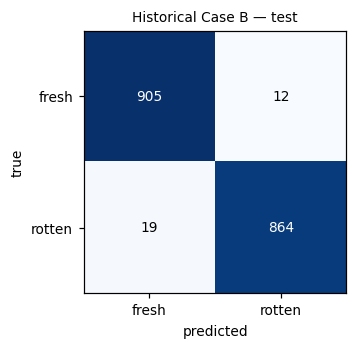

Historical errors: 31
No new test evaluation was performed.


In [14]:
historical_test_results = pd.DataFrame([
    {
        "artifact": "Historical Case A — no PCA", "case": "A", "feature_case": "no_aug",
        "classifier": "svm", "split": "test", "accuracy": 0.9838888888888889,
        "macro_precision": 0.9839471980788521, "macro_recall": 0.9838306506889495,
        "macro_f1": 0.9838813220650806, "weighted_f1": 0.9838879187832723,
        "raw_feature_dim": 1920, "pca_feature_dim": None, "seconds": 8.69360308299838,
    },
    {
        "artifact": "Historical Case B — PCA(95%)", "case": "B", "feature_case": "no_aug",
        "classifier": "svm", "split": "test", "accuracy": 0.9827777777777778,
        "macro_precision": 0.9828692996501216, "macro_recall": 0.9826981478576924,
        "macro_f1": 0.9827688377828127, "weighted_f1": 0.982776251437174,
        "raw_feature_dim": 1920, "pca_feature_dim": 690, "seconds": 16.804477199999383,
    },
])
historical_case_b_cm = pd.DataFrame(
    [[905, 12], [19, 864]], index=CLASSES, columns=CLASSES,
)
historical_case_b_report = pd.DataFrame([
    {"class": "fresh", "precision": 0.9794372294372294, "recall": 0.9869138495092693,
     "f1": 0.9831613253666486, "support": 917},
    {"class": "rotten", "precision": 0.9863013698630136, "recall": 0.9784824462061155,
     "f1": 0.9823763501989767, "support": 883},
])
display(historical_test_results)
display(historical_case_b_report)
plot_confusion_matrix(historical_case_b_cm.to_numpy(), "Historical Case B — test")
plt.show()
print("Historical errors:", int(historical_case_b_cm.to_numpy().sum() - np.trace(historical_case_b_cm)))
print("No new test evaluation was performed.")

## 12. Validation qualitative and error analysis

### 12.1 DenseNet-201 validation error samples

The images below are matched to the selected DenseNet-201 + PCA(95%) + SVM run's committed
validation predictions. They show both correct and incorrect predictions. No test image is used.
Rotten→fresh errors receive special attention because accepting spoiled produce as fresh is the
more safety-relevant failure direction.


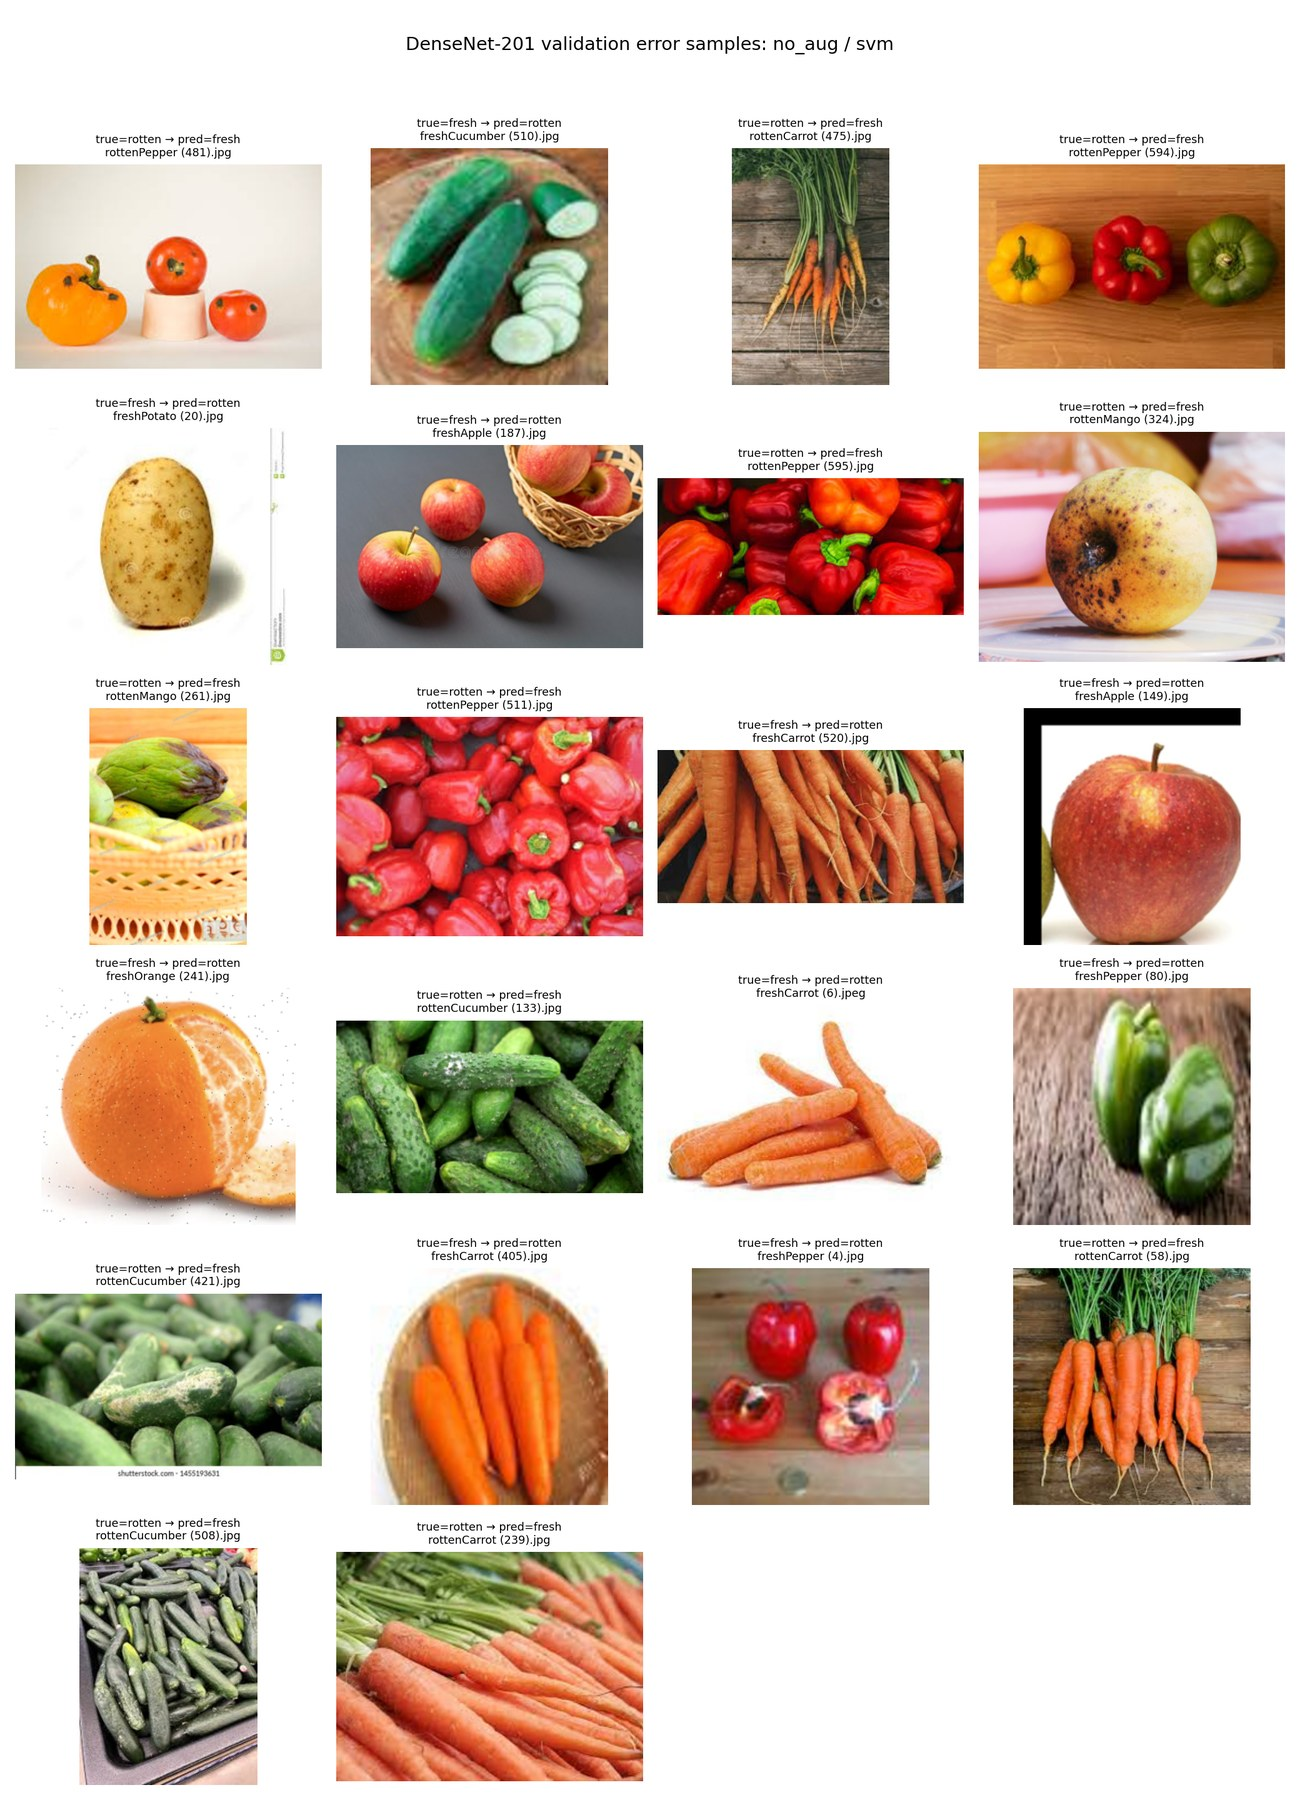


100%|██████████| 870M/870M [00:11<00:00, 77.3MB/s]

Extracting files...


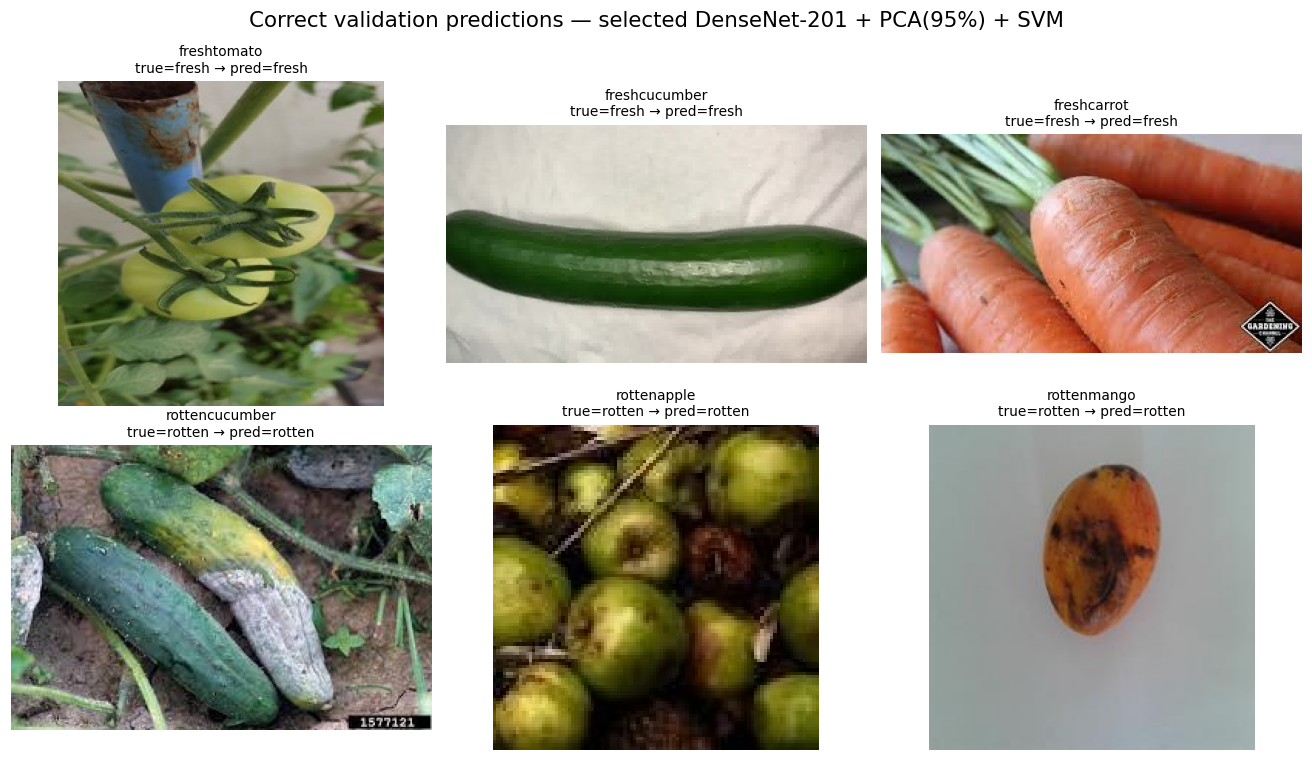

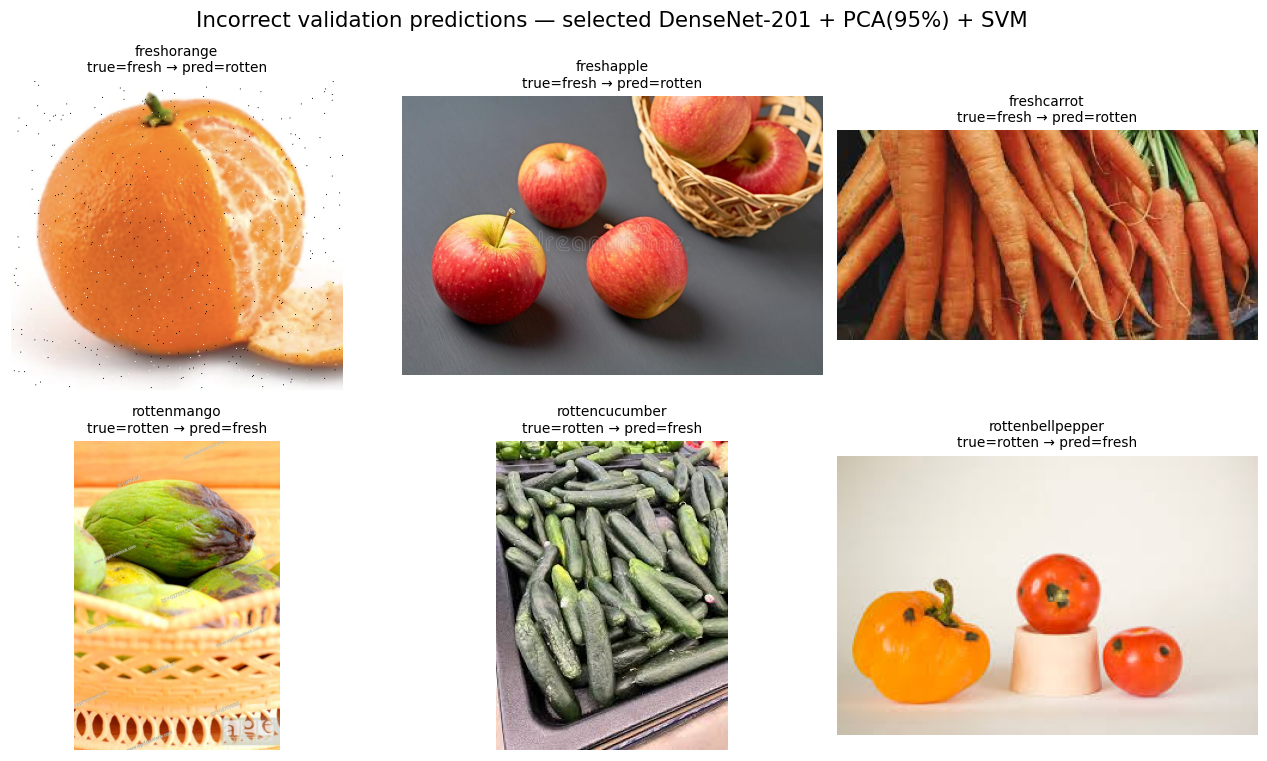

,label,true_binary,pred_binary,errors
0,rottenbellpepper,rotten,fresh,4
1,freshcarrot,fresh,rotten,3
2,rottencarrot,rotten,fresh,3
3,rottencucumber,rotten,fresh,3
4,freshbellpepper,fresh,rotten,2
5,freshapple,fresh,rotten,2
6,rottenmango,rotten,fresh,2
7,freshpotato,fresh,rotten,1
8,freshcucumber,fresh,rotten,1
9,freshorange,fresh,rotten,1


,true_binary,pred_binary,errors
0,fresh,rotten,10
1,rotten,fresh,12


Total selected-model validation errors: 22 / 1801
Rotten → fresh errors are the more safety-relevant failure direction.


In [15]:
import re
import subprocess

PROJECT_REPO_URL = "https://github.com/DDCcheng/project.git"


def portable_basename(value):
    return re.split(r"[\\/]", str(value))[-1].casefold()


def resolve_project_repository():
    if REPOSITORY_ROOT is not None:
        return REPOSITORY_ROOT
    if not ALLOW_REPOSITORY_DOWNLOAD:
        return None
    target = WORK_DIR / "group_project_repository"
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1", PROJECT_REPO_URL, str(target)], check=True)
    return target


def balanced_sample(frame, group_column, number_per_group, random_state):
    return pd.concat([
        group.sample(n=min(number_per_group, len(group)), random_state=random_state)
        for _, group in frame.groupby(group_column, sort=True)
    ], ignore_index=True)


def show_prediction_examples(frame, title, number_columns=3):
    number_rows = int(np.ceil(len(frame) / number_columns))
    fig, axes = plt.subplots(number_rows, number_columns, figsize=(4 * number_columns, 3.5 * number_rows))
    axes = np.atleast_1d(axes).ravel()
    for axis, (_, row) in zip(axes, frame.iterrows()):
        with Image.open(row["local_filepath"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row['label']}\ntrue={row['true_binary']} → pred={row['pred_binary']}", fontsize=9)
        axis.axis("off")
    for axis in axes[len(frame):]:
        axis.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()


project_repository = resolve_project_repository() if RUN_QUALITATIVE_REBUILD else None

if project_repository is not None:
    prediction_file = project_repository / "results" / "tables" / "densenet201_no_aug_svm_val_predictions.csv"
    validation_predictions = pd.read_csv(prediction_file)
    if validation_predictions["correct"].dtype != bool:
        validation_predictions["correct"] = validation_predictions["correct"].astype(str).str.lower().eq("true")
    error_rows = validation_predictions[~validation_predictions["correct"]].copy()
    error_summary = (
        error_rows.groupby(["label", "true_binary", "pred_binary"]).size()
        .rename("errors").reset_index().sort_values("errors", ascending=False)
    )
    direction_summary = (
        error_rows.groupby(["true_binary", "pred_binary"]).size().rename("errors").reset_index()
    )
    display(error_summary.head(20)); display(direction_summary)
    print(f"Committed selected-model validation errors: {len(error_rows)} / {len(validation_predictions)}")
else:
    validation_predictions = None
    error_summary = pd.DataFrame(columns=["label", "true_binary", "pred_binary", "errors"])
    direction_summary = pd.DataFrame([
        {"true_binary": "fresh", "pred_binary": "rotten", "errors": 10},
        {"true_binary": "rotten", "pred_binary": "fresh", "errors": 12},
    ])
    display(direction_summary)
    print("Standalone recorded summary: 22 selected-model validation errors / 1,801 rows.")

if RUN_QUALITATIVE_REBUILD:
    if project_repository is None:
        raise FileNotFoundError("Repository prediction artifacts are required to rebuild image grids")
    if DATA_DIR is None or not Path(DATA_DIR).exists():
        if kagglehub is None:
            raise ImportError("Install kagglehub or set DATA_DIR before rebuilding image grids")
        DATA_DIR = Path(kagglehub.dataset_download(DATASET_HANDLE))
    all_images = scan_images(Path(DATA_DIR)).copy()
    all_images["lookup_key"] = all_images["label"].map(normalise_label) + "::" + all_images["filepath"].map(portable_basename)
    if all_images["lookup_key"].duplicated().any():
        raise ValueError("Ambiguous label/filename keys in local dataset")
    path_lookup = all_images.set_index("lookup_key")["filepath"]
    validation_predictions["lookup_key"] = (
        validation_predictions["label"].map(normalise_label)
        + "::" + validation_predictions["filepath"].map(portable_basename)
    )
    validation_predictions["local_filepath"] = validation_predictions["lookup_key"].map(path_lookup)
    if validation_predictions["local_filepath"].isna().any():
        raise FileNotFoundError("Some committed validation rows could not be matched to local images")
    correct_examples = balanced_sample(
        validation_predictions[validation_predictions["correct"]], "true_binary", 3, SEED,
    )
    wrong_examples = balanced_sample(
        validation_predictions[~validation_predictions["correct"]], "true_binary", 3, SEED,
    )
    show_prediction_examples(correct_examples, "Correct validation predictions")
    show_prediction_examples(wrong_examples, "Incorrect validation predictions")

print("Rotten → fresh errors are the more safety-relevant failure direction.")


### 12.2 ResNeXt-101 validation error samples

For the **ResNeXt-101 + PCA(95%) + RBF-SVM** validation diagnostic, there were **85 errors out of 1,801 validation images**.

- **Fresh → rotten:** 36
- **Rotten → fresh:** 49

These are **ResNeXt validation errors**, not final DenseNet test errors. They are included to analyse the limitations of the ResNeXt backbone and to show that many errors come from visually ambiguous freshness cues, such as lighting changes, cluttered backgrounds, unusual viewpoints, and subtle decay.

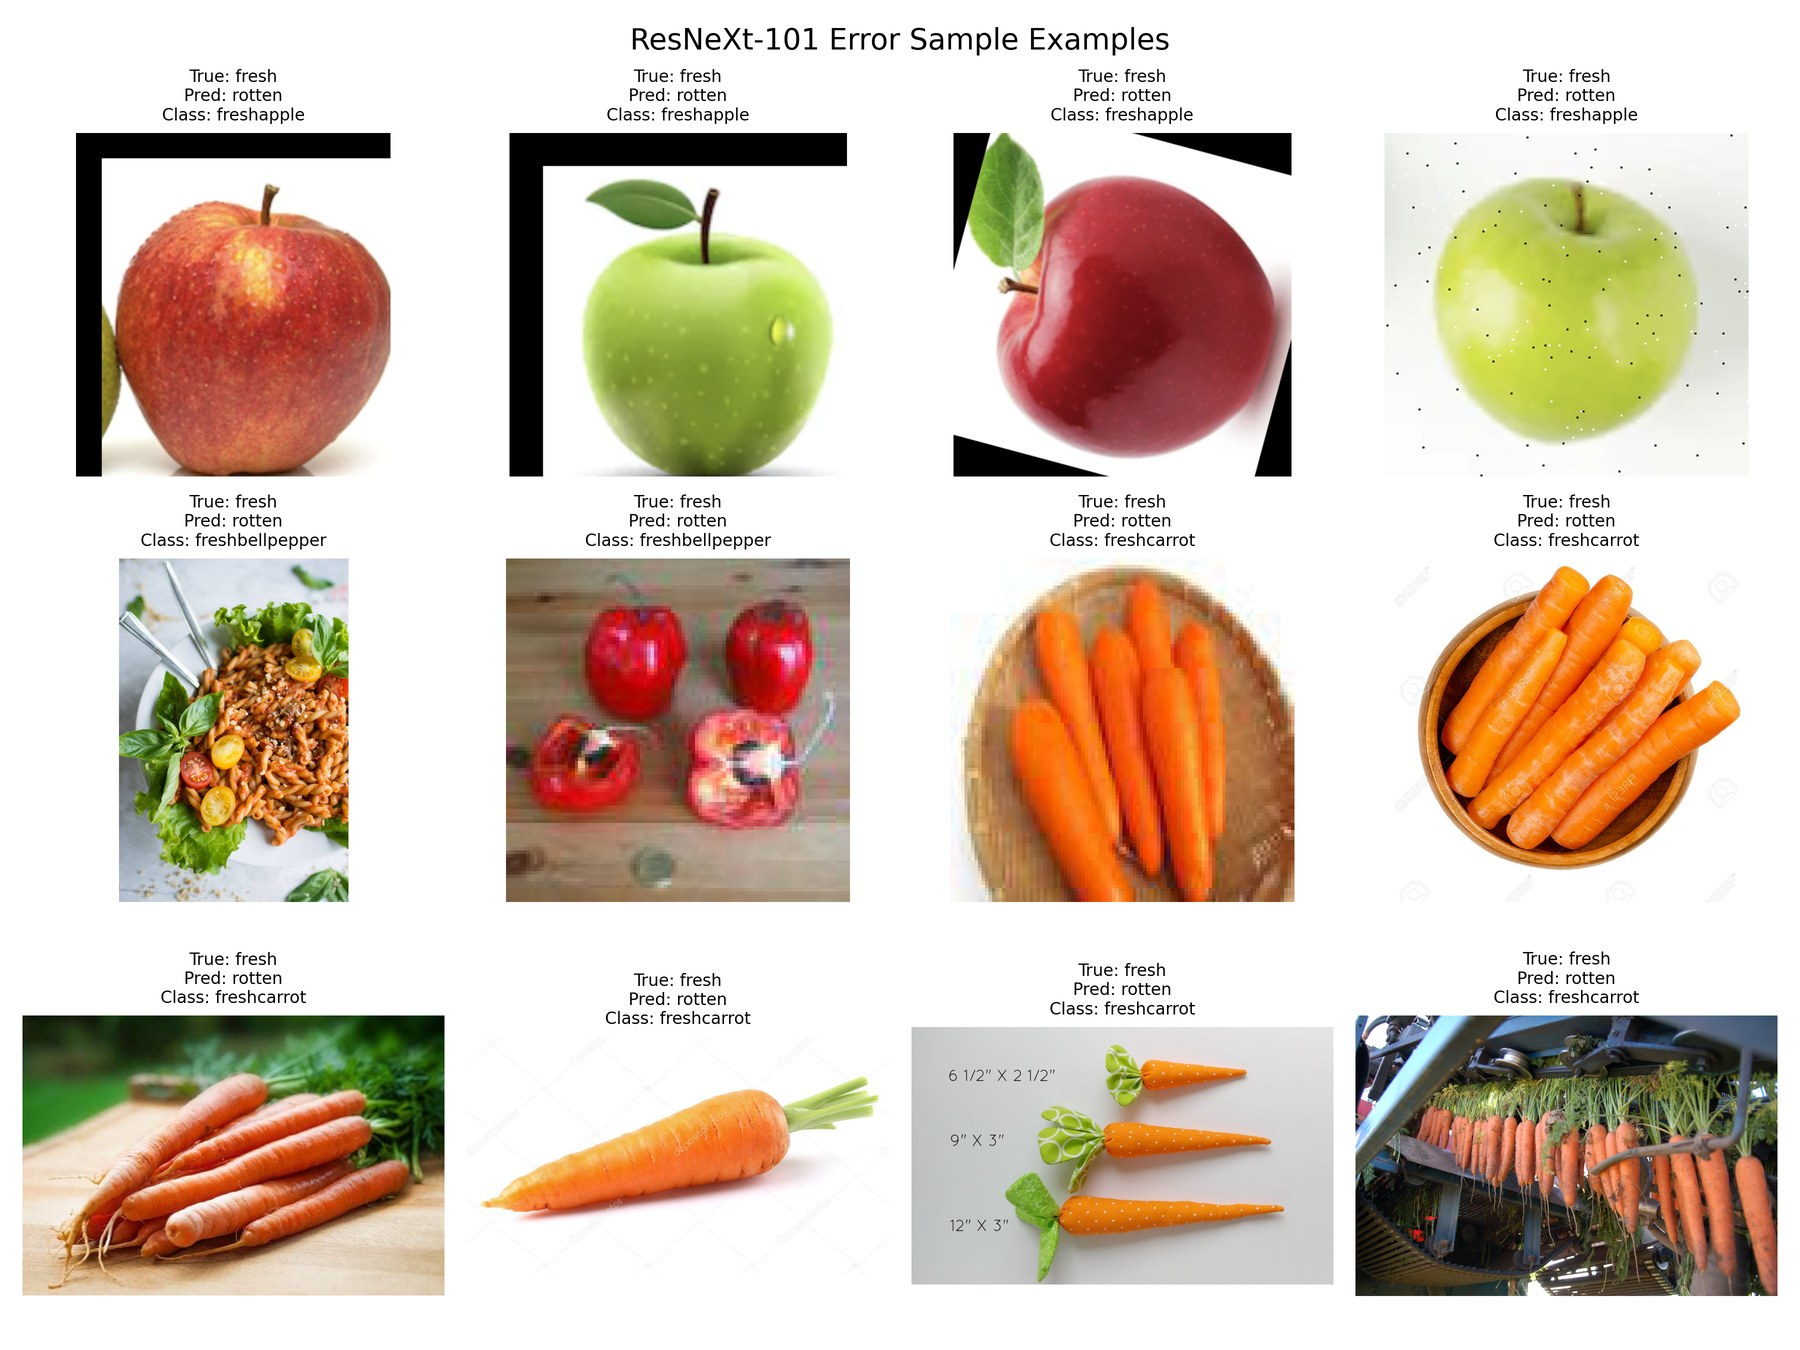


### 12.3 ResNeXt-101 binary and original-class diagnostics

The Member-3 diagnostic retrains the fixed Case-D RBF-SVM on train-only standardized/PCA features, saves its fresh/rotten confusion matrix and groups binary errors by the original produce folder. A separate 20-class SVM reuses the same train-fitted representation to show which produce categories are confused. The 20-class result is diagnostic only, it is not mixed into the binary model leaderboard.

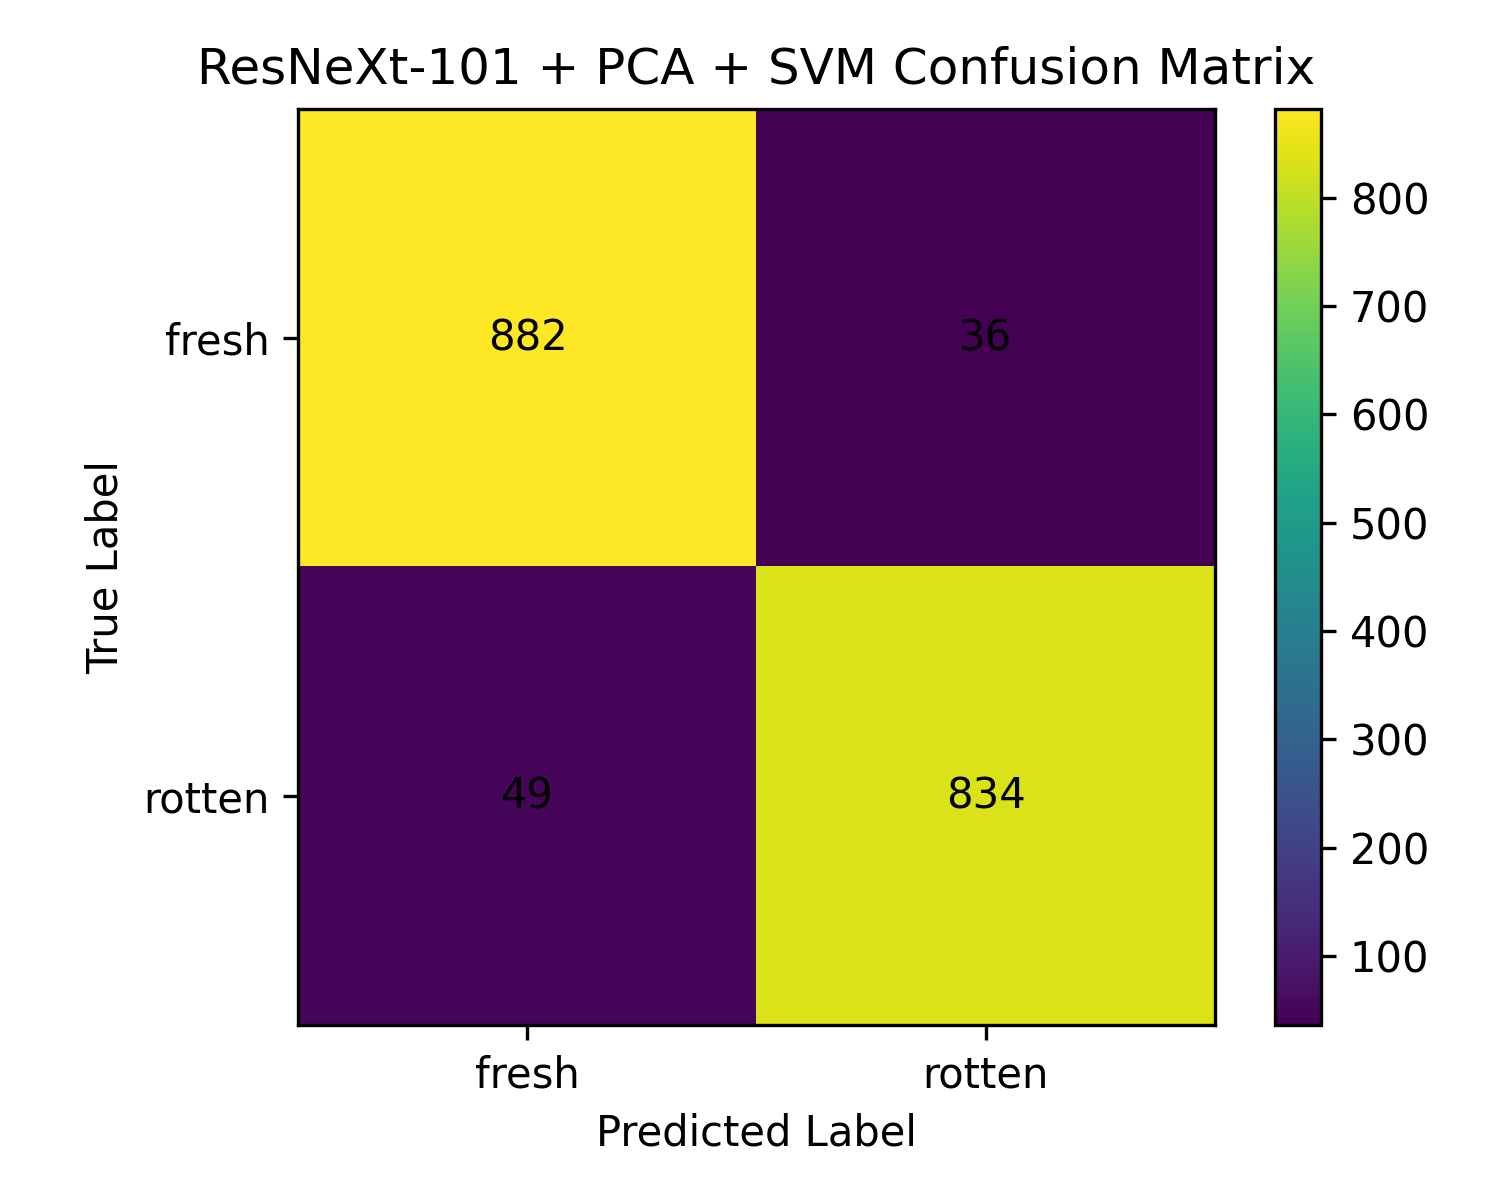

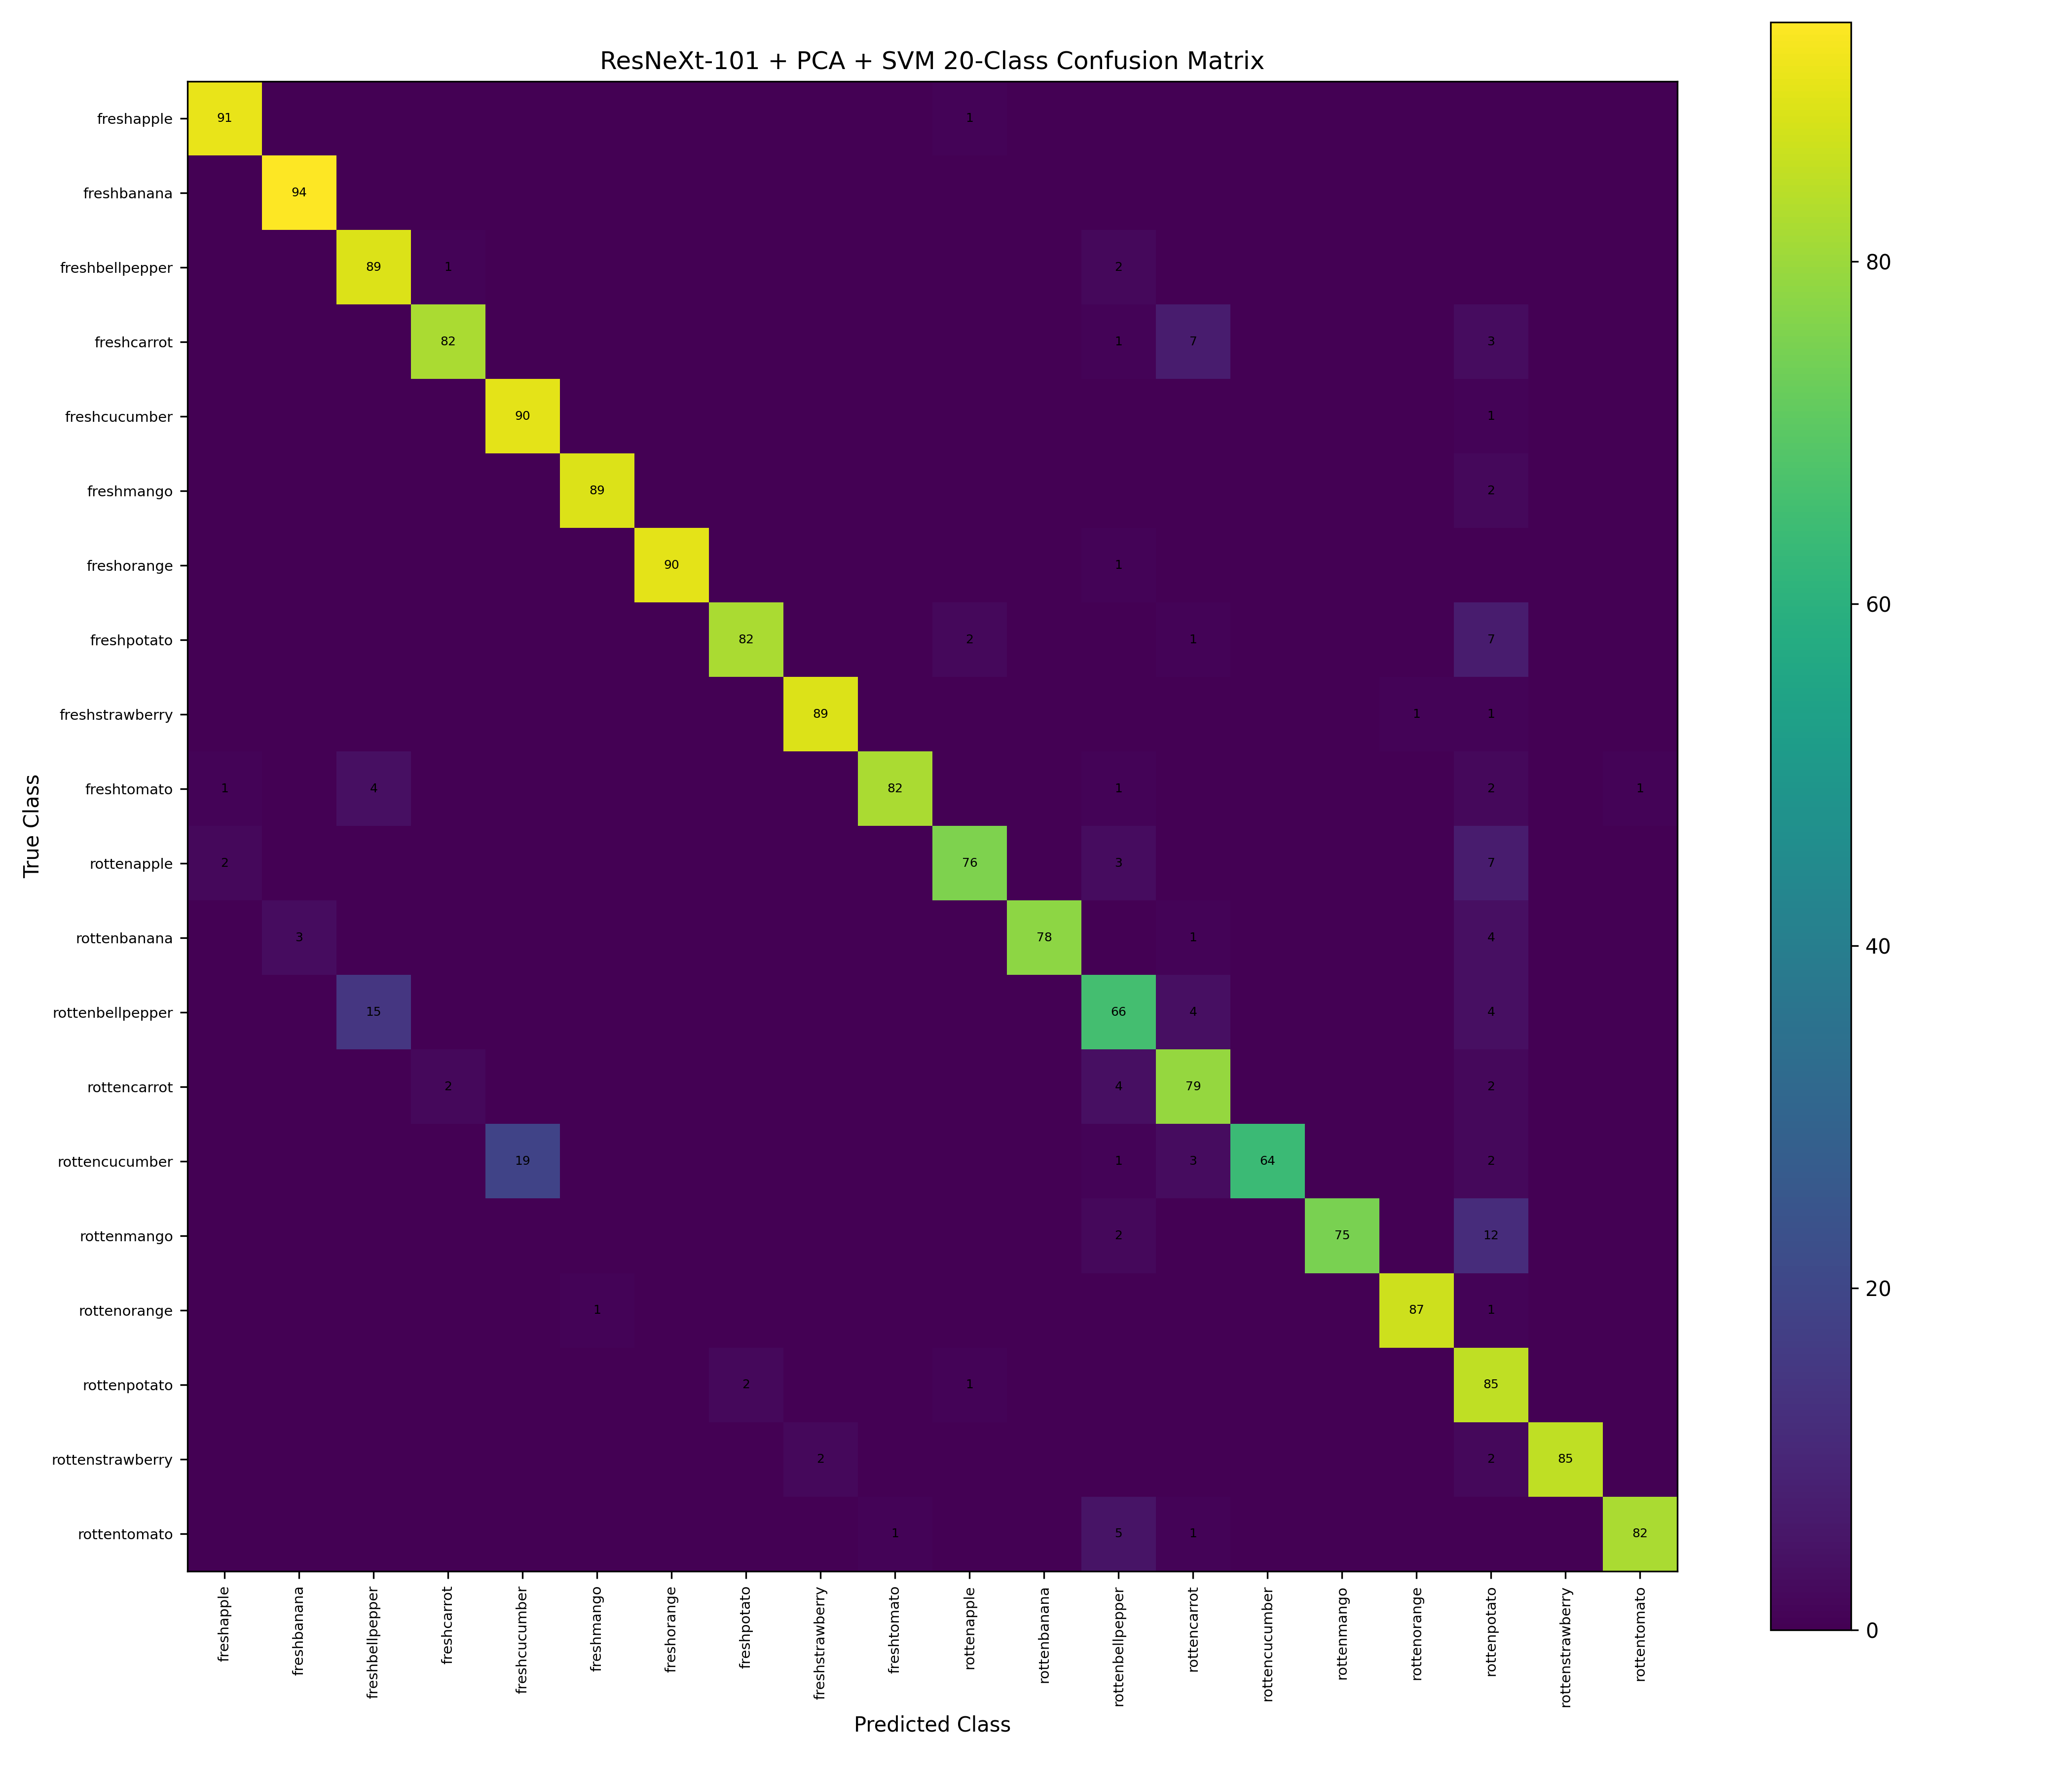


In [ ]:
def run_resnext_diagnostics(features, original_labels, splits, file_list=None):
    original_labels = np.asarray(original_labels).astype(str)
    splits = np.asarray(splits).astype(str)
    binary_labels = np.asarray([binary_label(value) for value in original_labels])
    train_mask, val_mask = splits == "train", splits == "val"

    scaler = StandardScaler().fit(features[train_mask])
    train_scaled = scaler.transform(features[train_mask])
    val_scaled = scaler.transform(features[val_mask])
    pca = PCA(n_components=0.95, svd_solver="full", random_state=SEED).fit(train_scaled)
    train_pca, val_pca = pca.transform(train_scaled), pca.transform(val_scaled)

    binary_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
    binary_model.fit(train_pca, binary_labels[train_mask])
    binary_pred = binary_model.predict(val_pca)
    binary_matrix = confusion_matrix(binary_labels[val_mask], binary_pred, labels=CLASSES)
    errors = pd.DataFrame({
        "original_class": original_labels[val_mask],
        "true_label": binary_labels[val_mask], "predicted_label": binary_pred,
    })
    if file_list is not None:
        errors["filepath"] = file_list.loc[file_list["split"].eq("val"), "filepath"].to_numpy()
    errors = errors[errors["true_label"].ne(errors["predicted_label"])].reset_index(drop=True)
    error_distribution = errors["original_class"].value_counts().rename_axis("original_class").reset_index(name="num_errors")

    class20_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
    class20_model.fit(train_pca, original_labels[train_mask])
    class20_pred = class20_model.predict(val_pca)
    class20_names = np.asarray(sorted(np.unique(original_labels)))
    class20_matrix = confusion_matrix(original_labels[val_mask], class20_pred, labels=class20_names)
    return {
        "pca_components": int(pca.n_components_), "binary_predictions": binary_pred,
        "binary_confusion": binary_matrix, "binary_errors": errors,
        "error_distribution": error_distribution, "class20_predictions": class20_pred,
        "class20_confusion": class20_matrix, "class20_names": class20_names,
    }


## 13. Training-only PCA and t-SNE visualisation

The four plots below use only training features: DenseNet-201 PCA, DenseNet-201 t-SNE,
ResNeXt-101 PCA and ResNeXt-101 t-SNE. Each backbone uses a seed-42 sample of at most 1,500
training rows. Standardisation and the visualisation transforms are fitted only to that sampled
training data. These plots are descriptive and are not used for classifier selection.


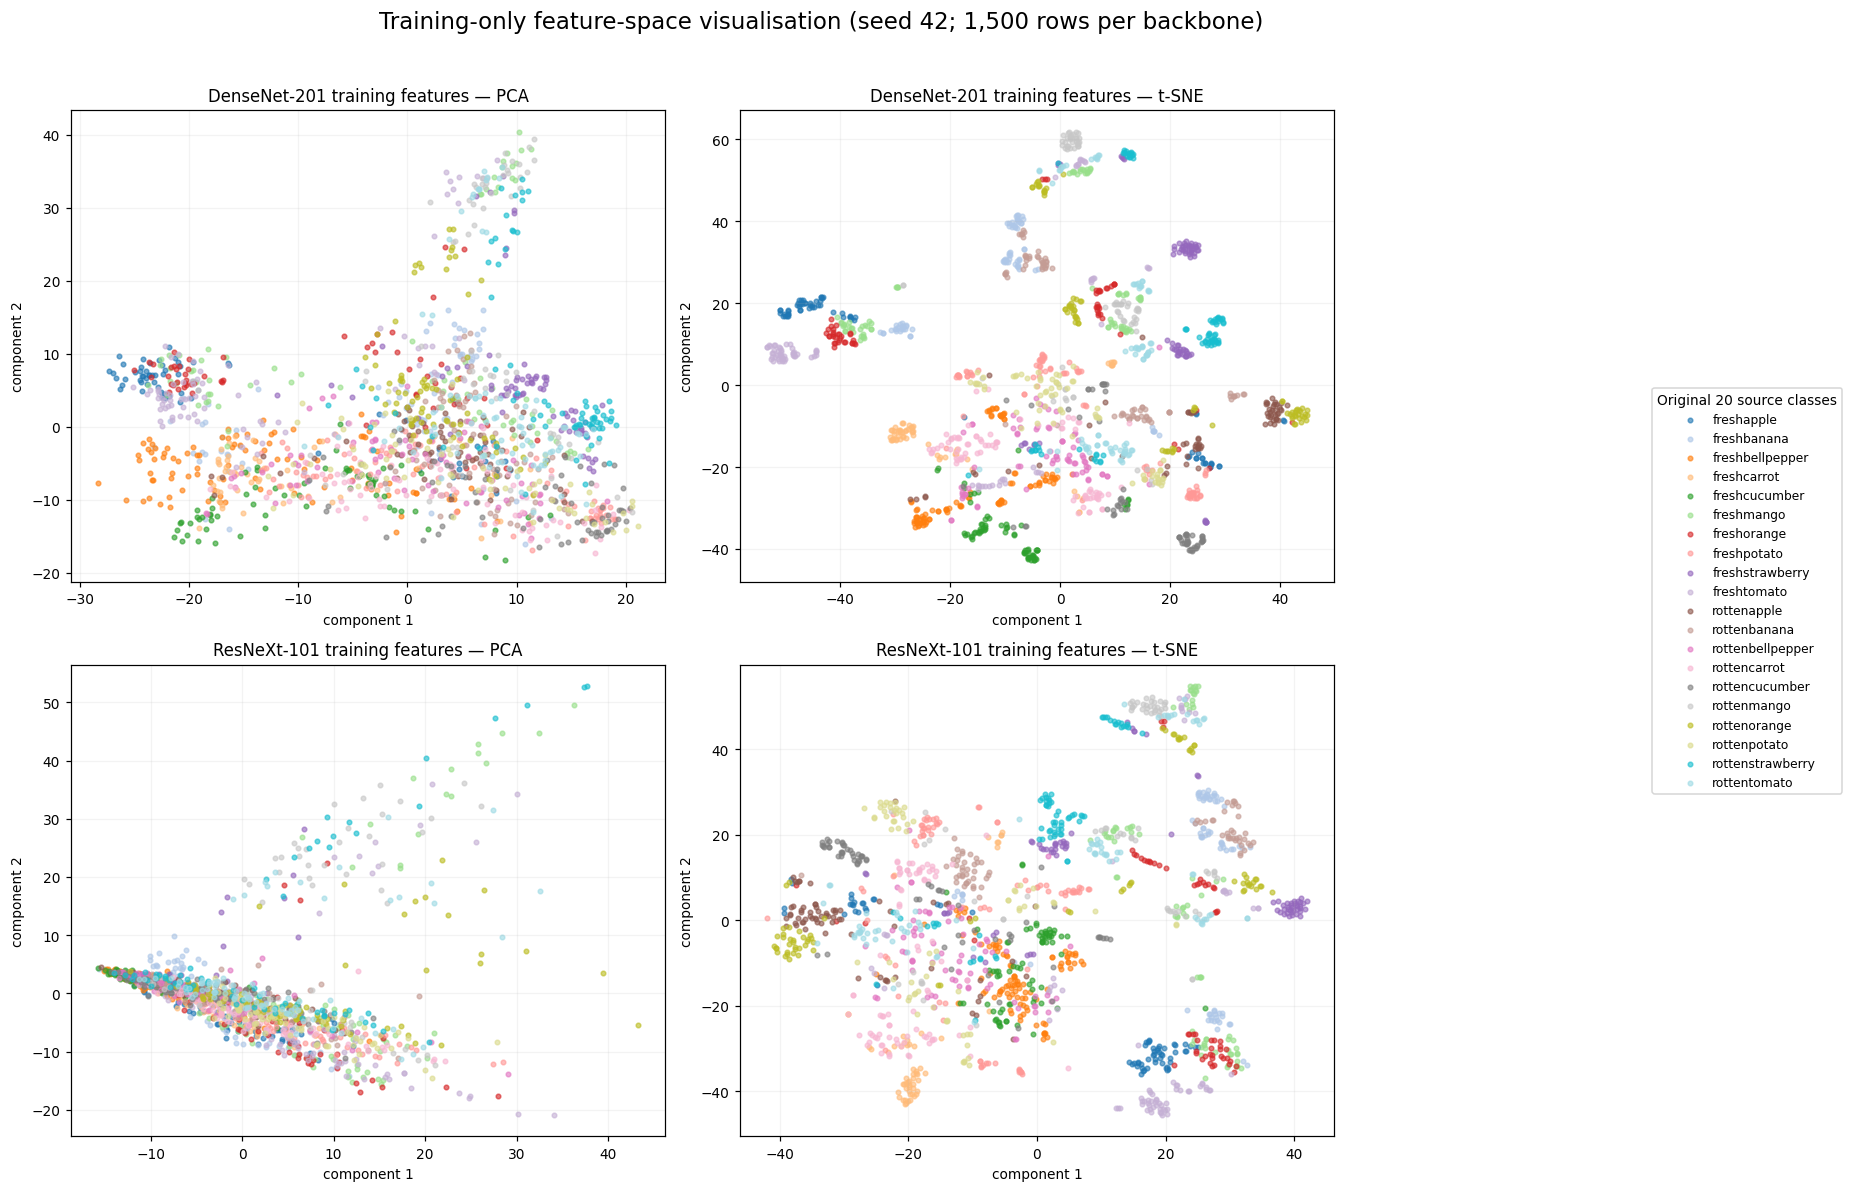

DenseNet visualisation source: train only | sampled rows: 1500
ResNeXt visualisation source: train only | sampled rows: 1500
Neither PCA nor t-SNE visualisation was used for model selection.


In [16]:
from sklearn.manifold import TSNE


def make_train_only_embeddings(features, labels, sample_size=1500):
    rng = np.random.default_rng(SEED)
    chosen = rng.choice(
        len(features),
        size=min(sample_size, len(features)),
        replace=False,
    )
    sampled_features = np.asarray(features[chosen], dtype=np.float32)
    sampled_labels = np.asarray(labels[chosen]).astype(str)

    scaled = StandardScaler().fit_transform(sampled_features)
    pca_2d = PCA(
        n_components=2,
        svd_solver="randomized",
        random_state=SEED,
    ).fit_transform(scaled)
    pca_50d = PCA(
        n_components=min(50, scaled.shape[1], scaled.shape[0] - 1),
        svd_solver="randomized",
        random_state=SEED,
    ).fit_transform(scaled)
    tsne_2d = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=30,
        init="pca",
        learning_rate="auto",
    ).fit_transform(pca_50d)
    return sampled_labels, pca_2d, tsne_2d


def scatter_by_source_class(axis, embedding, labels, title):
    classes = np.unique(labels)
    colour_map = plt.get_cmap("tab20", len(classes))
    for index, class_name in enumerate(classes):
        mask = labels == class_name
        axis.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=9,
            alpha=0.62,
            color=colour_map(index),
            label=class_name,
        )
    axis.set_title(title)
    axis.set_xlabel("component 1")
    axis.set_ylabel("component 2")
    axis.grid(alpha=0.15)


if RUN_EMBEDDING_REBUILD:
    project_repository = resolve_project_repository()
    if project_repository is None:
        raise FileNotFoundError(
            "A cloned repository is required only when rebuilding PCA and t-SNE figures"
        )
    
    feature_root = project_repository / "results" / "features"
    
    # DenseNet files below contain training rows only.
    dense_features = np.load(
        feature_root / "no_aug" / "densenet201_train_features.npy",
        mmap_mode="r",
    )
    dense_labels = np.load(
        feature_root / "no_aug" / "densenet201_train_labels.npy",
        mmap_mode="r",
    )
    
    # ResNeXt file contains all splits, so select train before fitting either visualiser.
    resnext_features_all = np.load(
        feature_root / "resnext101_aug_features.npy",
        mmap_mode="r",
    )
    resnext_labels_all = np.load(
        feature_root / "resnext101_aug_labels.npy",
        mmap_mode="r",
    )
    resnext_splits = np.load(
        feature_root / "resnext101_aug_splits.npy",
        mmap_mode="r",
    )
    resnext_train_indices = np.flatnonzero(np.asarray(resnext_splits).astype(str) == "train")
    resnext_train_features = resnext_features_all[resnext_train_indices]
    resnext_train_labels = resnext_labels_all[resnext_train_indices]
    
    dense_vis_labels, dense_pca, dense_tsne = make_train_only_embeddings(
        dense_features,
        dense_labels,
    )
    resnext_vis_labels, resnext_pca, resnext_tsne = make_train_only_embeddings(
        resnext_train_features,
        resnext_train_labels,
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    scatter_by_source_class(
        axes[0, 0],
        dense_pca,
        dense_vis_labels,
        "DenseNet-201 training features — PCA",
    )
    scatter_by_source_class(
        axes[0, 1],
        dense_tsne,
        dense_vis_labels,
        "DenseNet-201 training features — t-SNE",
    )
    scatter_by_source_class(
        axes[1, 0],
        resnext_pca,
        resnext_vis_labels,
        "ResNeXt-101 training features — PCA",
    )
    scatter_by_source_class(
        axes[1, 1],
        resnext_tsne,
        resnext_vis_labels,
        "ResNeXt-101 training features — t-SNE",
    )
    
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Original 20 source classes",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8,
    )
    fig.suptitle(
        "Training-only feature-space visualisation (seed 42; 1,500 rows per backbone)",
        fontsize=15,
    )
    plt.tight_layout(rect=(0, 0, 0.82, 0.96))
    plt.show()
    
    print("DenseNet visualisation source: train only | sampled rows:", len(dense_vis_labels))
    print("ResNeXt visualisation source: train only | sampled rows:", len(resnext_vis_labels))
    print("Neither PCA nor t-SNE visualisation was used for model selection.")
    
else:
    print("Embedding rebuild skipped; committed PCA/t-SNE figures are stored under results/figures/.")


## 14. Conclusions and limitations

**Validation findings**

- No-augmentation DenseNet-201 + PCA(95%) + SVM achieved the best validation Macro-F1 of 0.9878.
- The frozen ResNet-18 + PCA(95%) + SVM control achieved validation Macro-F1 0.9761.
- The selected DenseNet pipeline exceeded the frozen ResNet-18 comparison baseline by approximately 1.17 percentage points.
- Under matched augmented PCA(95%) + SVM settings, DenseNet-201 (0.9772) exceeded fusion (0.9739)
  and ResNeXt-101 (0.9528). More complex features therefore did not guarantee a better result.
- SVM was strongest among the tested classical classifiers. LDA was generally faster, whereas
  Bagging was weaker and slower on the dense CNN embeddings.
- PCA reduced dimensionality and runtime, but its performance effect depended on the backbone and
  classifier. PCA(95% explained variance), rather than fixed 100/200/300 dimensions, was used.
- Mild augmentation did not improve the two strongest reported settings. Colour and fine surface
  texture are important freshness cues, so cropping and colour perturbation may remove useful
  evidence. However, one seed and one augmentation policy do not establish causality.

**Error analysis**

- The selected DenseNet validation run made 22 errors among 1,801 images: 10 fresh→rotten and
  12 rotten→fresh.
- Visually ambiguous decay, uneven lighting, background clutter, viewpoints and overlapping
  colour/texture cues are plausible error sources.
- Rotten→fresh mistakes are the more safety-relevant direction and should be prioritised in future
  thresholding and external validation.

**Limitations**

- The 20 original produce categories are collapsed into one binary target.
- The dataset comes from one source, so external-domain generalisation is not established.
- Classical-classifier hyperparameters and the augmentation policy were not exhaustively tuned.
- Frozen-feature augmentation contains one deterministic augmented view per training image.
- Training time varies with hardware and library versions.
- Two historical test evaluations already exist. Those test figures are descriptive rather than
  a strictly untouched one-shot estimate. A separate external test set is required for a new
  unbiased final assessment, and this notebook deliberately performs no new test evaluation.


## 15. Optional interactive prediction demo

This upload interface refits the validation-selected DenseNet-201 + PCA(95%) + SVM pipeline using
committed training features only, extracts DenseNet-201 features from one new uploaded image and
returns a fresh/rotten prediction. It never loads validation or test arrays. The SVM decision
score is a margin, not a calibrated probability.


The demo uses the validation-selected DenseNet-201 + PCA(95%) + RBF-SVM pipeline fitted on committed training features only. It is intentionally opt-in so `Run All` never blocks on a file-upload dialog. After generating the DenseNet training features, set `RUN_INTERACTIVE_DEMO=True` in Section 1 and rerun this section. The SVM output is a decision margin, not a calibrated probability.

The saved widget output is intentionally cleared because static notebook previews do not render `ipywidgets` reliably. Run this section in Jupyter or Colab with `RUN_INTERACTIVE_DEMO=True` to open the upload interface.


In [ ]:
if RUN_INTERACTIVE_DEMO:
    try:
        import ipywidgets as widgets
    except ImportError as error:
        raise ImportError("Install ipywidgets to run the optional upload demo") from error

    demo_cache = feature_cache_paths("densenet201", "no_aug", "train")
    if not demo_cache["X"].is_file() or not demo_cache["y"].is_file():
        raise FileNotFoundError(
            "Run DenseNet-201 no-augmentation feature extraction before enabling the demo"
        )
    demo_train_features = np.load(demo_cache["X"], mmap_mode="r")
    demo_train_labels = np.load(demo_cache["y"]).astype(str)

    DEMO_PIPELINE = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, svd_solver="full", random_state=SEED)),
        ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)),
    ])
    DEMO_PIPELINE.fit(np.asarray(demo_train_features), np.asarray(demo_train_labels).astype(str))
    DEMO_BACKBONE = build_frozen_backbone("densenet201")
    DEMO_TRANSFORM = make_transform("no_aug", "val", "densenet201")

    def uploaded_file_bytes(upload_value):
        if isinstance(upload_value, dict):
            filename, metadata = next(iter(upload_value.items()))
            return filename, bytes(metadata["content"])
        metadata = upload_value[0]
        return metadata["name"], bytes(metadata["content"])

    def predict_uploaded_image(image):
        tensor = DEMO_TRANSFORM(image.convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            features = DEMO_BACKBONE(tensor).detach().cpu().numpy()
        predicted_class = str(DEMO_PIPELINE.predict(features)[0])
        decision_score = float(np.ravel(DEMO_PIPELINE.decision_function(features))[0])
        return predicted_class, decision_score

    upload_widget = widgets.FileUpload(accept="image/*", multiple=False, description="Upload image")
    predict_button = widgets.Button(description="Predict freshness", button_style="success")
    demo_output = widgets.Output()

    def on_predict_clicked(_):
        with demo_output:
            clear_output(wait=True)
            try:
                filename, content = uploaded_file_bytes(upload_widget.value)
                image = Image.open(io.BytesIO(content)).convert("RGB")
                display(image.copy().resize((320, 320)))
                predicted_class, decision_score = predict_uploaded_image(image)
                print(f"File: {filename}")
                print(f"Prediction: {predicted_class.upper()}")
                print(f"SVM decision margin: {decision_score:.4f}")
            except Exception as error:
                print(f"Demo error: {type(error).__name__}: {error}")

    predict_button.on_click(on_predict_clicked)
    display(widgets.VBox([upload_widget, predict_button, demo_output]))
else:
    print("Interactive demo skipped by default. Set RUN_INTERACTIVE_DEMO=True to enable it.")
